# OMI Real Estate Quotations — Exploratory Analysis

This notebook builds a reproducible analytical dataset from the semiannual **OMI (Osservatorio del Mercato Immobiliare)** quotations published by the *Agenzia delle Entrate*.

**Source:** Agenzia delle Entrate — Osservatorio del Mercato Immobiliare.


## 1. Setup

The notebook keeps the analytical stack lightweight: `pandas` for data preparation, `numpy` for numerical transformations and `matplotlib` for visualization. The project root is resolved from the notebook location so the code does not depend on a specific working directory.


In [102]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / 'data' / 'raw' / 'quotations'

## 2. Load and consolidate the raw OMI releases

OMI quotations are supplied as one semicolon-separated CSV per semester. Each file is loaded independently so that unexpected files can be identified early and the reference period is retained explicitly.


## 3. Initial dataset inspection

Inspect the schema, temporal coverage and raw structure before changing any values.


In [103]:
omi = pd.read_parquet(
    PROJECT_ROOT / "data" / "processed" / "omi_quotations.parquet"
)

print(f"Number of rows: {omi.shape[0]}")
omi.head()

Number of rows: 7516495


,Area_territoriale,Regione,Prov,Comune_ISTAT,Comune_cat,Sez,Comune_amm,Comune_descrizione,Fascia,Zona,...,reference_year,reference_semester,reference_period,reference_date,Compr_mid,Loc_mid,Compr_spread,Loc_spread,Compr_spread_pct,Loc_spread_pct
0,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,395.0,NaN,150.0,NaN,37.974684,NaN
1,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,325.0,1.0,130.0,NaN,40.000000,NaN
2,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,325.0,1.0,130.0,NaN,40.000000,NaN
3,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,210.0,1.0,80.0,NaN,38.095238,NaN
4,SUD,ABRUZZO,AQ,13066001.0,N1AB,NaN,A018,ACCIANO,B,B1,...,2004,S1,2004-S1,2004-06-30,85.0,NaN,30.0,NaN,35.294118,NaN


## 4. Data Exploration


<Axes: xlabel='Descr_Tipologia'>

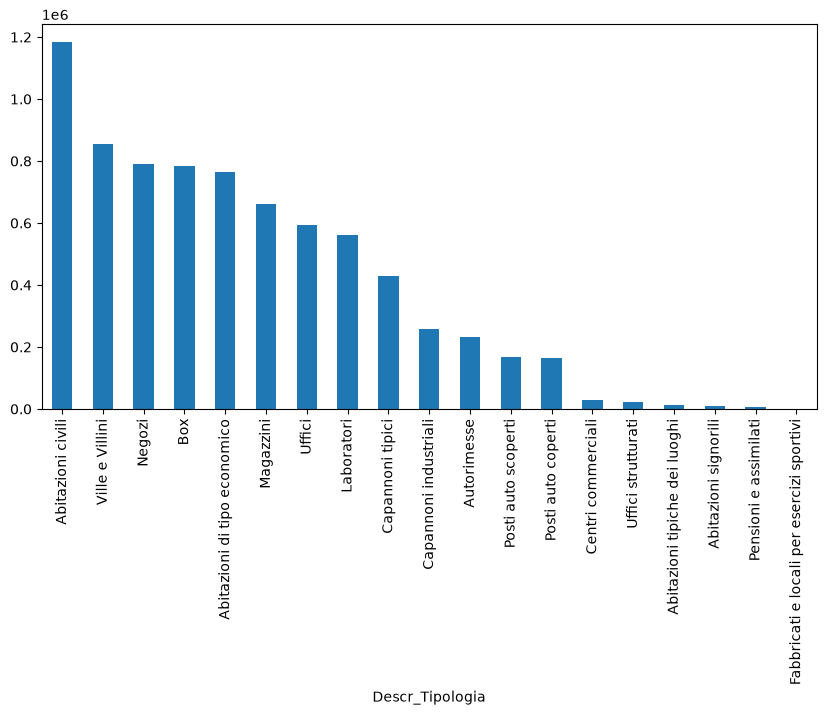

In [104]:
omi["Descr_Tipologia"].value_counts().plot(kind="bar", figsize=(10, 5))

### Residential Purchase Quotations

In [105]:
residential_mask = omi['Descr_Tipologia'].astype('string').str.contains('abitazion|villa', case=False, na=False)
residential = omi.loc[residential_mask].copy()
print(f'Residential observations: {len(residential):,}')

Residential observations: 1,971,694


#### National Trend

In [106]:
national_trend = (
    residential.groupby('reference_date', as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)

display(national_trend.tail(10))

,reference_date,median_compr_mid,mean_compr_mid,observations
34,2021-06-30,900.0,1087.043634,44323
35,2021-12-31,900.0,1084.901347,44550
36,2022-06-30,895.0,1086.832873,44568
37,2022-12-31,895.0,1091.734147,44581
38,2023-06-30,895.0,1096.249776,44622
39,2023-12-31,895.0,1099.863701,44663
40,2024-06-30,890.0,1102.279793,44583
41,2024-12-31,890.0,1107.890620,44327
42,2025-06-30,900.0,1115.333657,44342
43,2025-12-31,900.0,1124.300717,44349


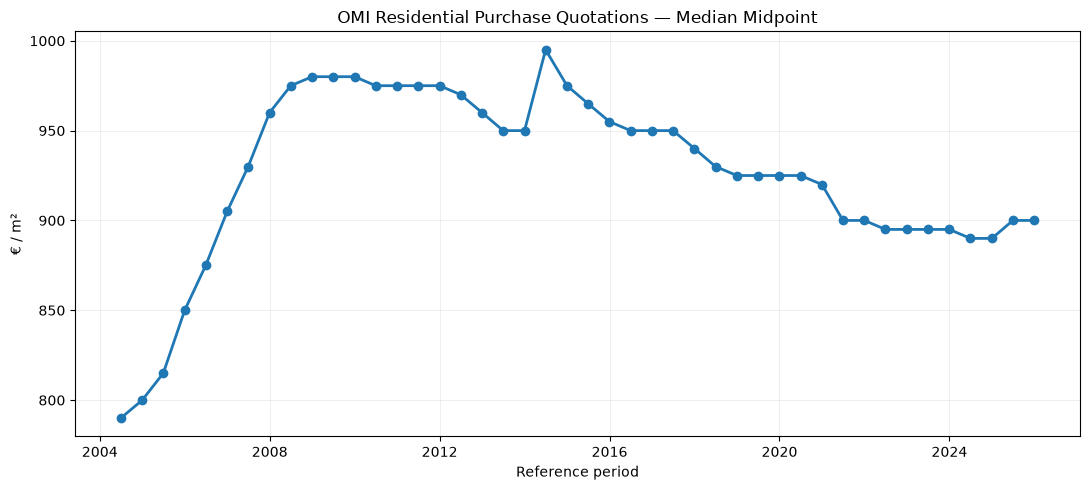

In [107]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national_trend['reference_date'], national_trend['median_compr_mid'], marker='o', linewidth=2)
ax.set_title('OMI Residential Purchase Quotations — Median Midpoint')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

#### Regional Inspection


In [108]:
regional_trend = (
    residential.groupby(['reference_date', "Regione"], as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)

display(regional_trend.tail(10))

,reference_date,Regione,median_compr_mid,mean_compr_mid,observations
870,2025-12-31,MOLISE,425.00,504.259962,527
871,2025-12-31,PIEMONTE,765.00,890.331683,4545
872,2025-12-31,PUGLIA,765.00,900.528933,1659
873,2025-12-31,SARDEGNA,725.00,997.329218,1215
874,2025-12-31,SICILIA,571.25,667.302383,2644
875,2025-12-31,TOSCANA,1250.00,1431.282051,1911
876,2025-12-31,TRENTINO-ALTO ADIGE,2150.00,2370.805471,1645
877,2025-12-31,UMBRIA,725.00,761.482906,585
878,2025-12-31,VALLE D'AOSTA/VALLE`E D'AOSTE,1275.00,1652.770833,480
879,2025-12-31,VENETO,1125.00,1246.821901,3178


##### Top 10

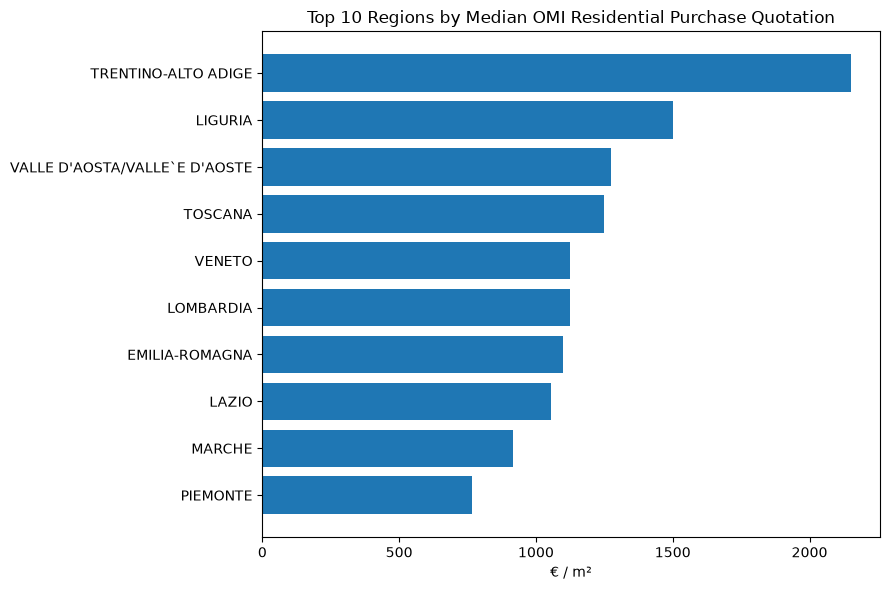

In [109]:
latest_date = regional_trend['reference_date'].max()

top_regions = (
    regional_trend[
        regional_trend['reference_date'].eq(latest_date)
    ]
    .nlargest(10, 'median_compr_mid')
    .sort_values('median_compr_mid')
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top_regions['Regione'],
    top_regions['median_compr_mid']
)

ax.set_title('Top 10 Regions by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()
plt.show()

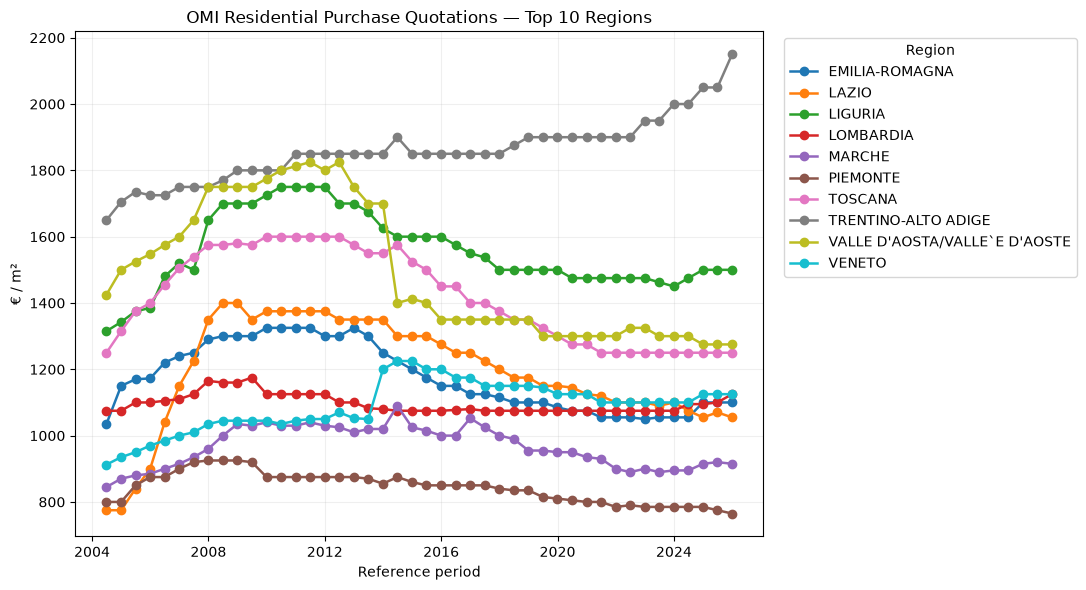

In [110]:
latest_date = regional_trend['reference_date'].max()

top_regions = (
    regional_trend[regional_trend['reference_date'].eq(latest_date)]
    .nlargest(10, 'median_compr_mid')['Regione']
)

plot_data = regional_trend[
    regional_trend['Regione'].isin(top_regions)
]

fig, ax = plt.subplots(figsize=(11, 6))

for regione, data in plot_data.groupby('Regione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.8,
        label=regione
    )

ax.set_title('OMI Residential Purchase Quotations — Top 10 Regions')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')

ax.grid(alpha=0.2)
ax.legend(
    title='Region',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

##### Last 10

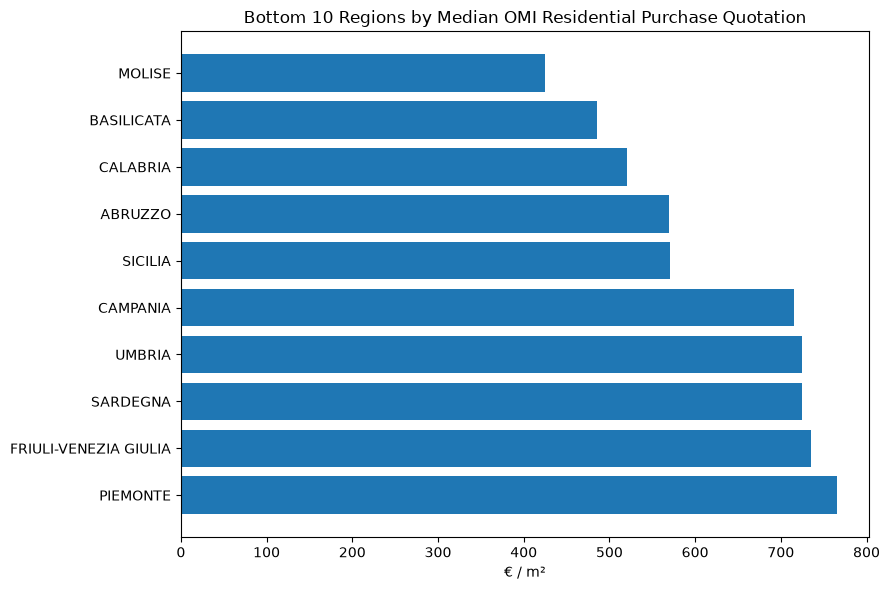

In [111]:
latest_date = regional_trend['reference_date'].max()

last_regions = (
    regional_trend[
        regional_trend['reference_date'].eq(latest_date)
    ]
    .nsmallest(10, 'median_compr_mid')
    .sort_values('median_compr_mid', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    last_regions['Regione'],
    last_regions['median_compr_mid']
)

ax.set_title('Bottom 10 Regions by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()

plt.show()

#### Provincial Inspection

In [112]:
provincial_trend = (
    residential
    .groupby(['reference_date', 'Prov'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = provincial_trend['reference_date'].max()

##### Top 20

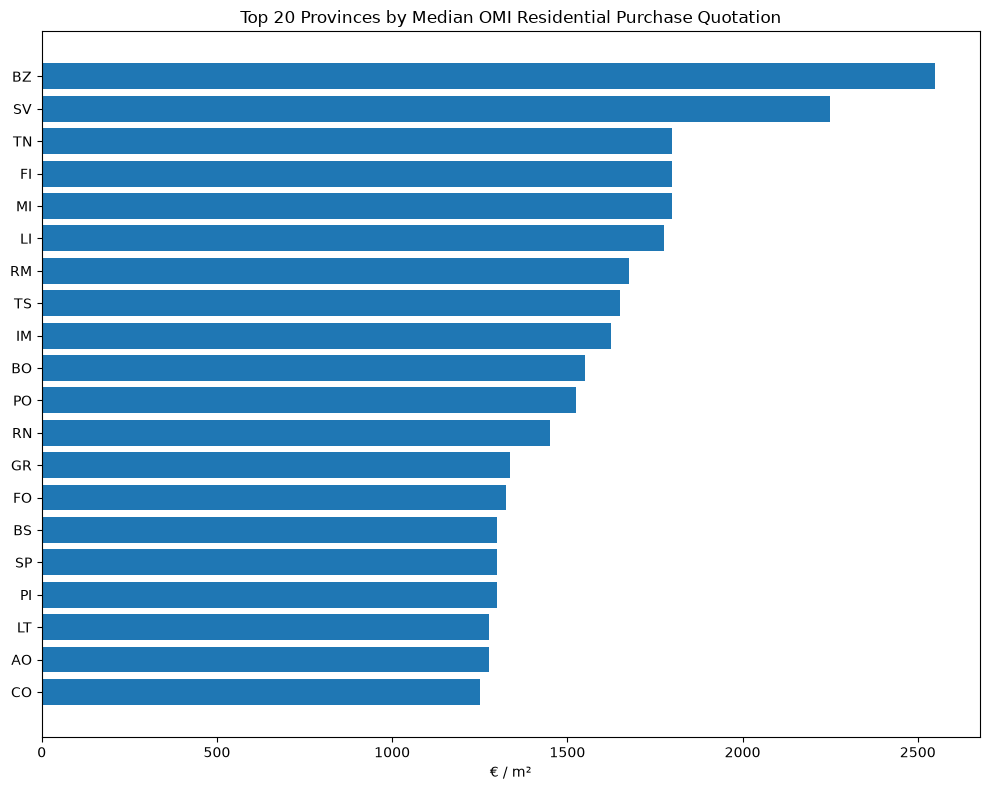

In [113]:
top_provinces = (
    provincial_trend[
        provincial_trend['reference_date'].eq(latest_date)
    ]
    .nlargest(20, 'median_compr_mid')
    .sort_values('median_compr_mid')
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_provinces['Prov'],
    top_provinces['median_compr_mid']
)

ax.set_title('Top 20 Provinces by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()

plt.show()

In [114]:
provincial_trend = (
    residential.groupby(['reference_date', "Prov"], as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)

display(provincial_trend.tail(10))

,reference_date,Prov,median_compr_mid,mean_compr_mid,observations
4478,2025-12-31,TV,1150.00,1207.291221,467
4479,2025-12-31,UD,775.00,820.537736,530
4480,2025-12-31,VA,1200.00,1262.097458,472
4481,2025-12-31,VB,925.00,999.872774,393
4482,2025-12-31,VC,645.00,748.481675,191
4483,2025-12-31,VE,1250.00,1558.449304,503
4484,2025-12-31,VI,1150.00,1142.216809,821
4485,2025-12-31,VR,1177.50,1434.568750,400
4486,2025-12-31,VT,925.00,971.548117,239
4487,2025-12-31,VV,411.25,489.698795,166


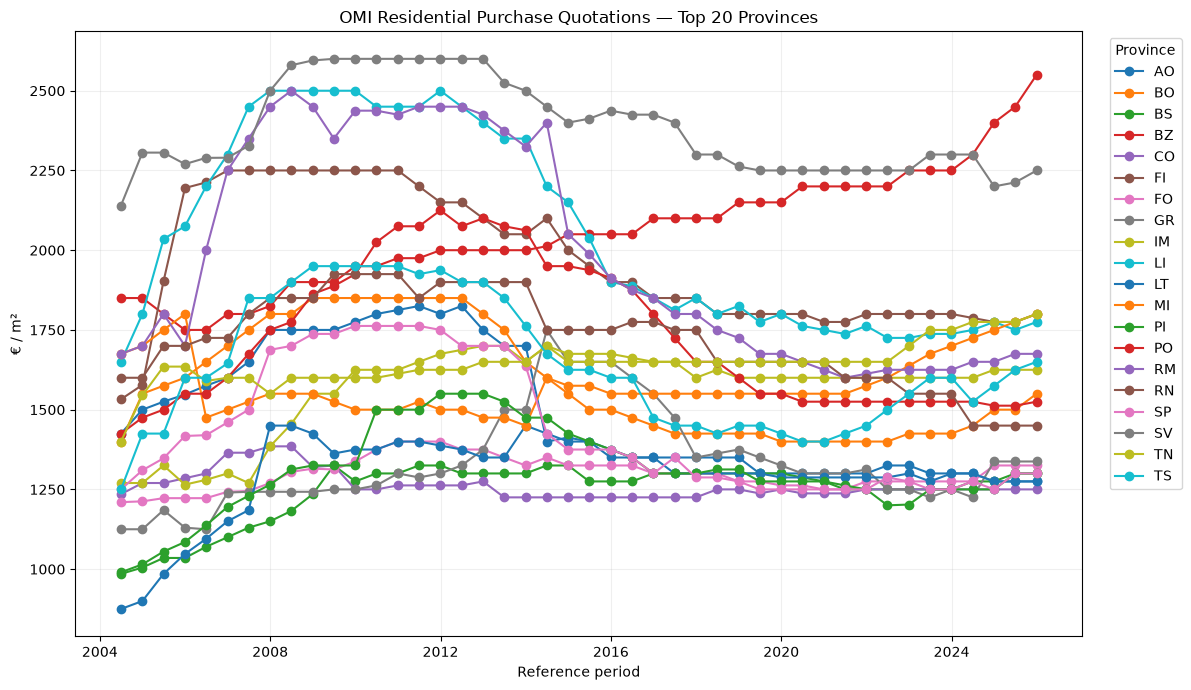

In [115]:
top_provinces_names = (
    provincial_trend[
        provincial_trend['reference_date'].eq(latest_date)
    ]
    .nlargest(20, 'median_compr_mid')['Prov']
)

plot_data = provincial_trend[
    provincial_trend['Prov'].isin(top_provinces_names)
]

fig, ax = plt.subplots(figsize=(12, 7))

for provincia, data in plot_data.groupby('Prov'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.5,
        label=provincia
    )

ax.set_title('OMI Residential Purchase Quotations — Top 20 Provinces')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Province',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()

plt.show()

##### Last 20

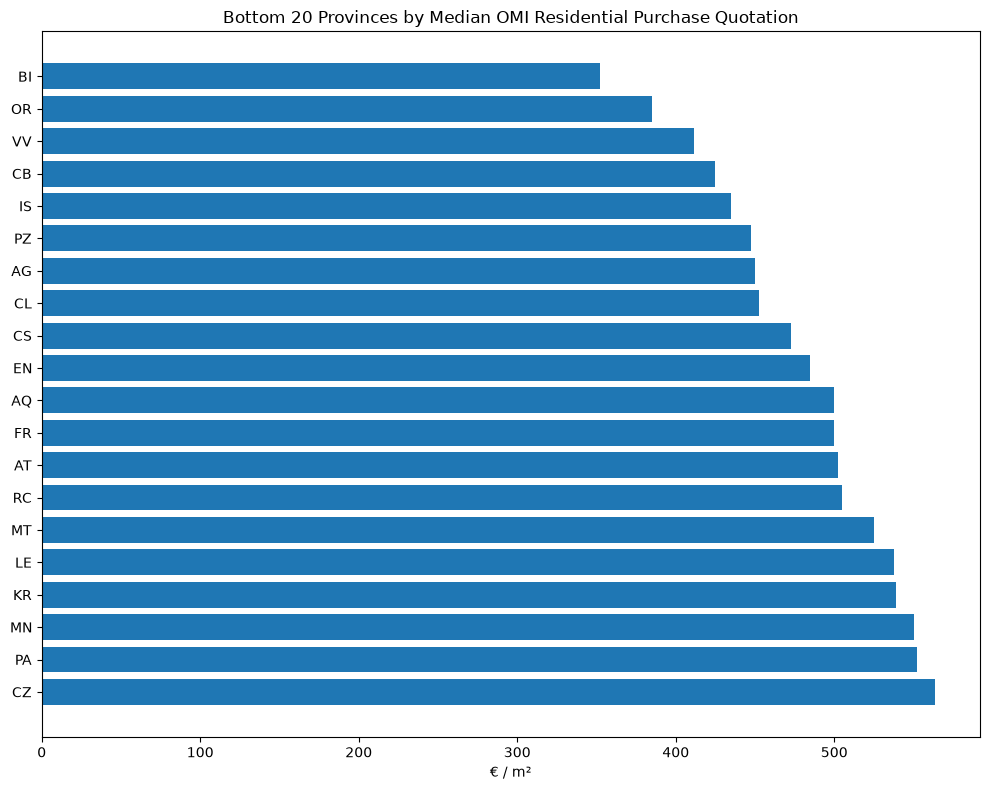

In [116]:
last_provinces = (
    provincial_trend[
        provincial_trend['reference_date'].eq(latest_date)
    ]
    .nsmallest(20, 'median_compr_mid')
    .sort_values('median_compr_mid', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    last_provinces['Prov'],
    last_provinces['median_compr_mid']
)

ax.set_title('Bottom 20 Provinces by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()

plt.show()

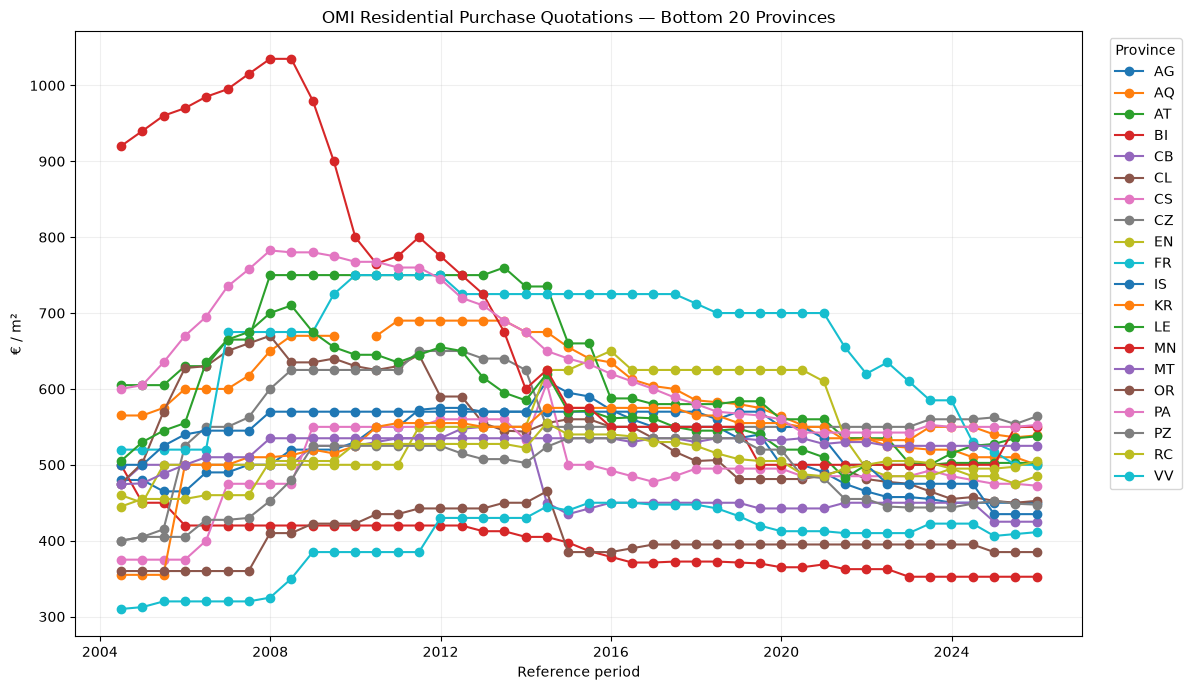

In [117]:
last_provinces_names = (
    provincial_trend[
        provincial_trend['reference_date'].eq(latest_date)
    ]
    .nsmallest(20, 'median_compr_mid')['Prov']
)

plot_data = provincial_trend[
    provincial_trend['Prov'].isin(last_provinces_names)
]

fig, ax = plt.subplots(figsize=(12, 7))

for provincia, data in plot_data.groupby('Prov'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.5,
        label=provincia
    )

ax.set_title('OMI Residential Purchase Quotations — Bottom 20 Provinces')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Province',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()

plt.show()

#### Municipal Inspection

In [118]:
municipal_trend = (
    residential
    .groupby(['reference_date', 'Comune_descrizione'], as_index=False)
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = municipal_trend['reference_date'].max()

##### Top 20

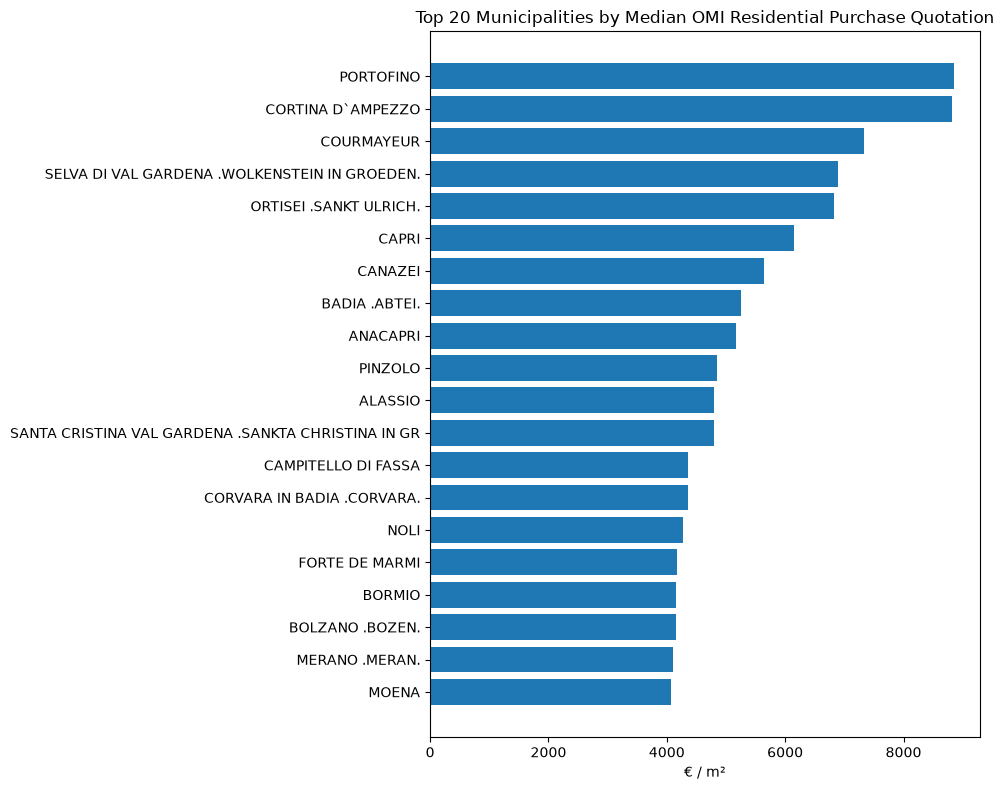

In [119]:
top_municipalities = (
    municipal_trend[
        municipal_trend['reference_date'].eq(latest_date)
    ]
    .nlargest(20, 'median_compr_mid')
    .sort_values('median_compr_mid')
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_municipalities['Comune_descrizione'],
    top_municipalities['median_compr_mid']
)

ax.set_title('Top 20 Municipalities by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()

plt.show()

In [120]:
municipal_trend = (
    residential.groupby(['reference_date', "Comune_descrizione"], as_index=False)
    .agg(median_compr_mid=('Compr_mid','median'), mean_compr_mid=('Compr_mid','mean'), observations=('Compr_mid','count'))
)

display(municipal_trend.tail(10))

,reference_date,Comune_descrizione,median_compr_mid,mean_compr_mid,observations
352366,2025-12-31,ZOPPOLA,700.00,696.875,8
352367,2025-12-31,ZOVENCEDO,937.50,860.000,4
352368,2025-12-31,ZUBIENA,336.25,358.125,4
352369,2025-12-31,ZUCCARELLO,1425.00,1425.000,1
352370,2025-12-31,ZUGLIANO,1087.50,1096.250,8
352371,2025-12-31,ZUGLIO,545.00,565.000,3
352372,2025-12-31,ZUMAGLIA,347.50,347.500,2
352373,2025-12-31,ZUMPANO,610.00,612.000,5
352374,2025-12-31,ZUNGOLI,451.25,461.250,8
352375,2025-12-31,ZUNGRI,351.25,351.250,2


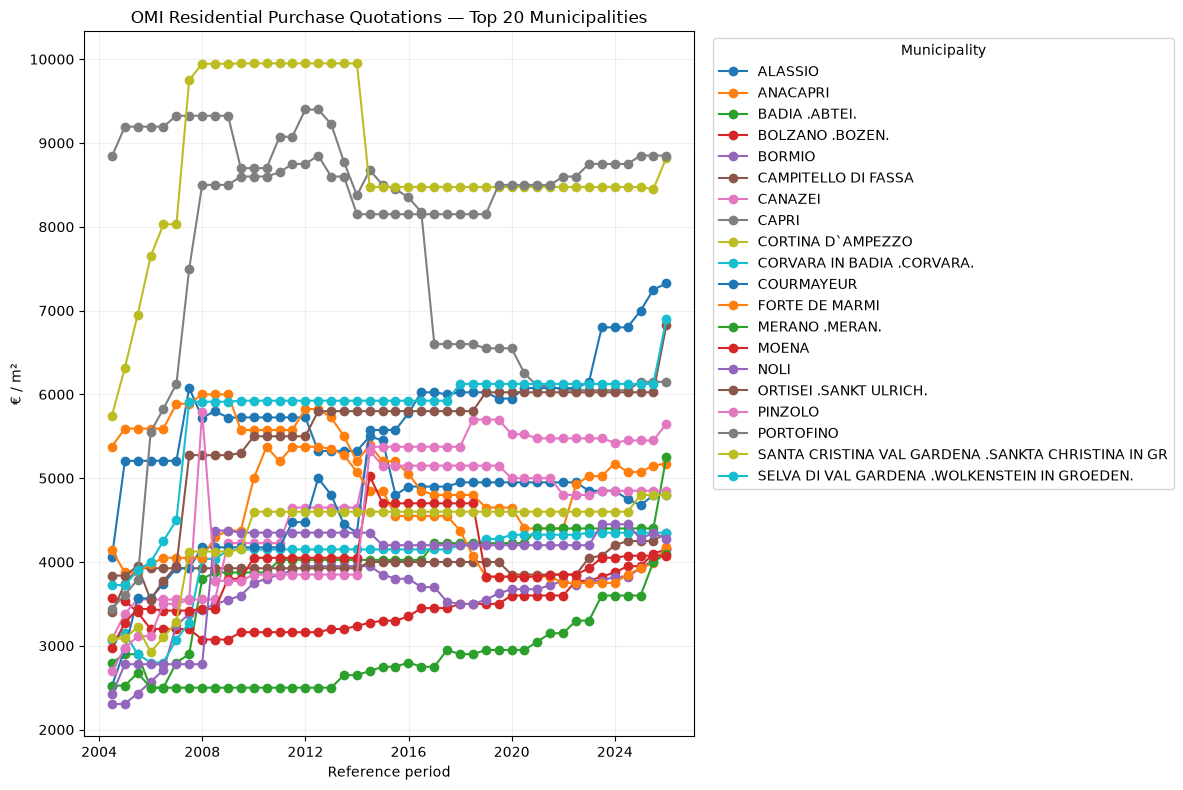

In [121]:
top_municipalities_names = (
    municipal_trend[
        municipal_trend['reference_date'].eq(latest_date)
    ]
    .nlargest(20, 'median_compr_mid')['Comune_descrizione']
)

plot_data = municipal_trend[
    municipal_trend['Comune_descrizione'].isin(top_municipalities_names)
]

fig, ax = plt.subplots(figsize=(12, 8))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.5,
        label=comune
    )

ax.set_title('OMI Residential Purchase Quotations — Top 20 Municipalities')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Municipality',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()

plt.show()

##### Last 20

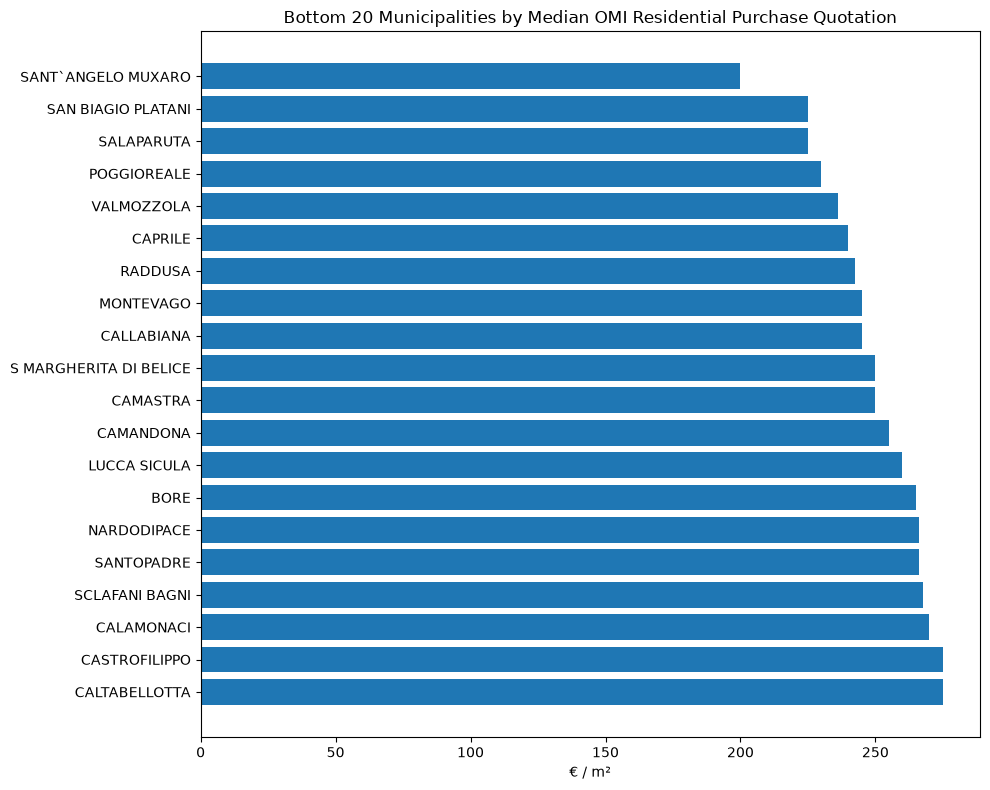

In [122]:
last_municipalities = (
    municipal_trend[
        municipal_trend['reference_date'].eq(latest_date)
    ]
    .nsmallest(20, 'median_compr_mid')
    .sort_values('median_compr_mid', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    last_municipalities['Comune_descrizione'],
    last_municipalities['median_compr_mid']
)

ax.set_title('Bottom 20 Municipalities by Median OMI Residential Purchase Quotation')
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()

plt.show()

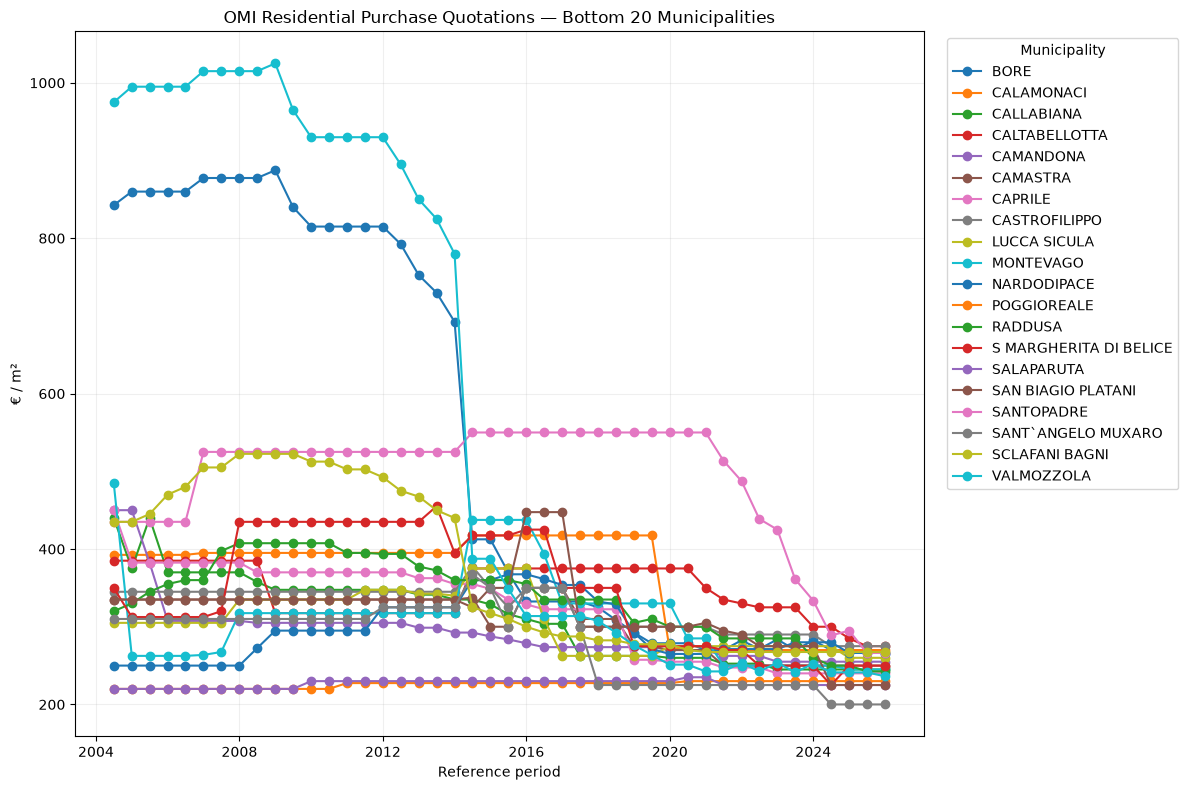

In [123]:
last_municipalities_names = (
    municipal_trend[
        municipal_trend['reference_date'].eq(latest_date)
    ]
    .nsmallest(20, 'median_compr_mid')['Comune_descrizione']
)

plot_data = municipal_trend[
    municipal_trend['Comune_descrizione'].isin(last_municipalities_names)
]

fig, ax = plt.subplots(figsize=(12, 8))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.5,
        label=comune
    )

ax.set_title('OMI Residential Purchase Quotations — Bottom 20 Municipalities')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Municipality',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()

plt.show()

#### Zone Inspection

In [124]:
municipal_zone_trend = (
    residential
    .groupby(
        ['reference_date', 'Comune_descrizione', 'Zona'],
        as_index=False
    )
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = municipal_zone_trend['reference_date'].max()

display(municipal_zone_trend.tail(10))

,reference_date,Comune_descrizione,Zona,median_compr_mid,mean_compr_mid,observations
1066871,2025-12-31,ZUGLIO,B1,575.00,575.00,2
1066872,2025-12-31,ZUGLIO,R1,545.00,545.00,1
1066873,2025-12-31,ZUMAGLIA,B1,347.50,347.50,2
1066874,2025-12-31,ZUMPANO,B1,526.25,526.25,2
1066875,2025-12-31,ZUMPANO,E1,830.00,830.00,2
1066876,2025-12-31,ZUMPANO,R1,347.50,347.50,1
1066877,2025-12-31,ZUNGOLI,B1,526.25,527.50,4
1066878,2025-12-31,ZUNGOLI,R1,396.25,395.00,4
1066879,2025-12-31,ZUNGRI,B2,422.50,422.50,1
1066880,2025-12-31,ZUNGRI,R2,280.00,280.00,1


##### Top 20

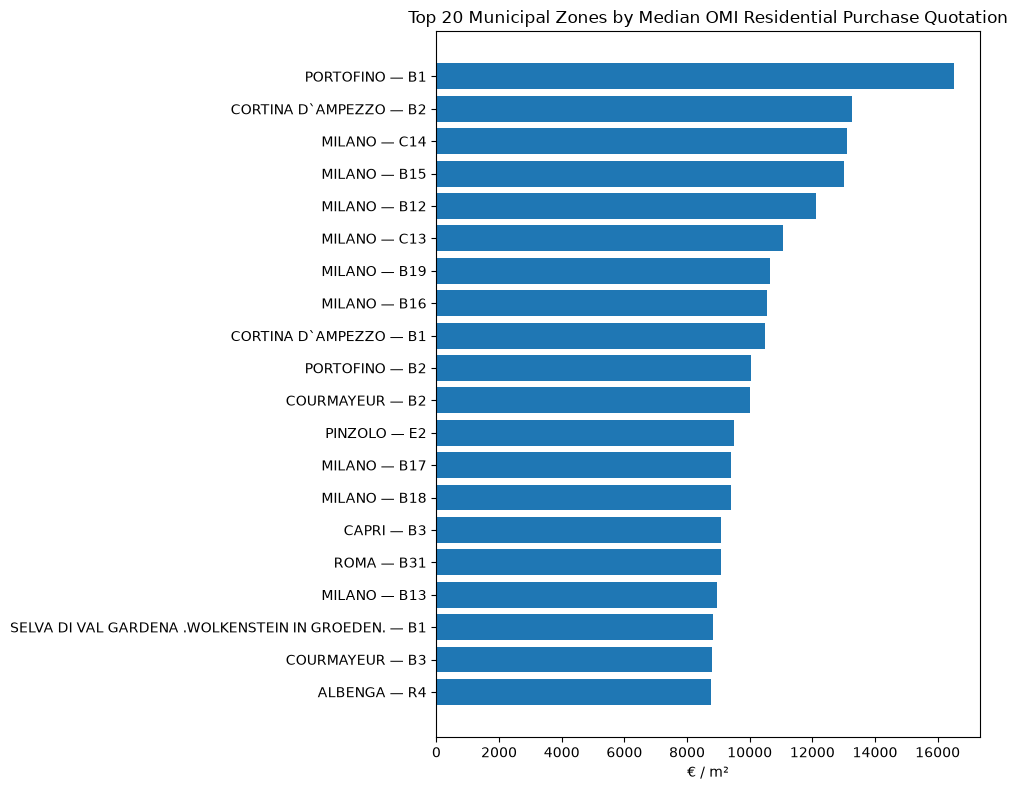

In [125]:
top_municipal_zones = (
    municipal_zone_trend[
        municipal_zone_trend['reference_date'].eq(latest_date)
    ]
    .nlargest(20, 'median_compr_mid')
    .sort_values('median_compr_mid')
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    top_municipal_zones['Comune_descrizione'] + ' — ' + top_municipal_zones['Zona'],
    top_municipal_zones['median_compr_mid']
)

ax.set_title(
    'Top 20 Municipal Zones by Median OMI Residential Purchase Quotation'
)
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()
plt.show()

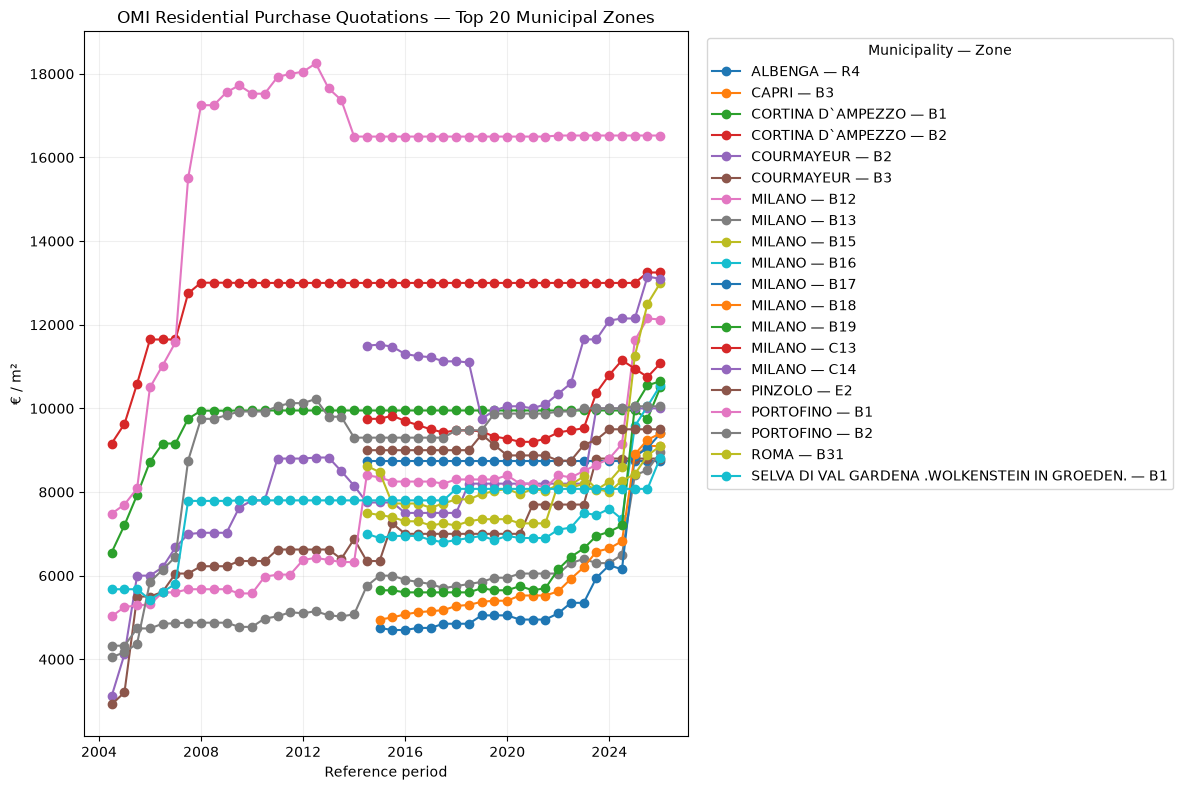

In [126]:
top_municipal_zones_names = (
    municipal_zone_trend[
        municipal_zone_trend['reference_date'].eq(latest_date)
    ]
    .nlargest(20, 'median_compr_mid')
    [['Comune_descrizione', 'Zona']]
)

plot_data = municipal_zone_trend.merge(
    top_municipal_zones_names,
    on=['Comune_descrizione', 'Zona'],
    how='inner'
)

fig, ax = plt.subplots(figsize=(12, 8))

for (comune, zona), data in plot_data.groupby(
    ['Comune_descrizione', 'Zona']
):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.5,
        label=f'{comune} — {zona}'
    )

ax.set_title(
    'OMI Residential Purchase Quotations — Top 20 Municipal Zones'
)
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')

ax.grid(alpha=0.2)

ax.legend(
    title='Municipality — Zone',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

##### Last 20

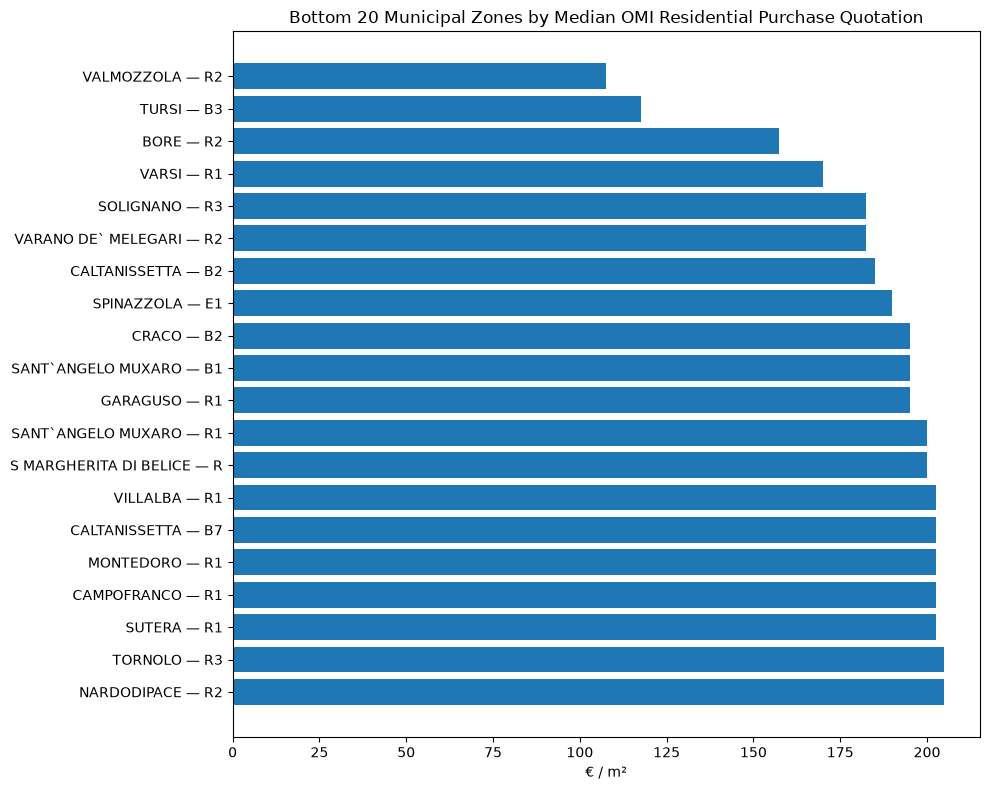

In [127]:
last_municipal_zones = (
    municipal_zone_trend[
        municipal_zone_trend['reference_date'].eq(latest_date)
    ]
    .nsmallest(20, 'median_compr_mid')
    .sort_values('median_compr_mid', ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    last_municipal_zones['Comune_descrizione'] + ' — ' + last_municipal_zones['Zona'],
    last_municipal_zones['median_compr_mid']
)

ax.set_title(
    'Bottom 20 Municipal Zones by Median OMI Residential Purchase Quotation'
)
ax.set_xlabel('€ / m²')
ax.set_ylabel('')

fig.tight_layout()
plt.show()

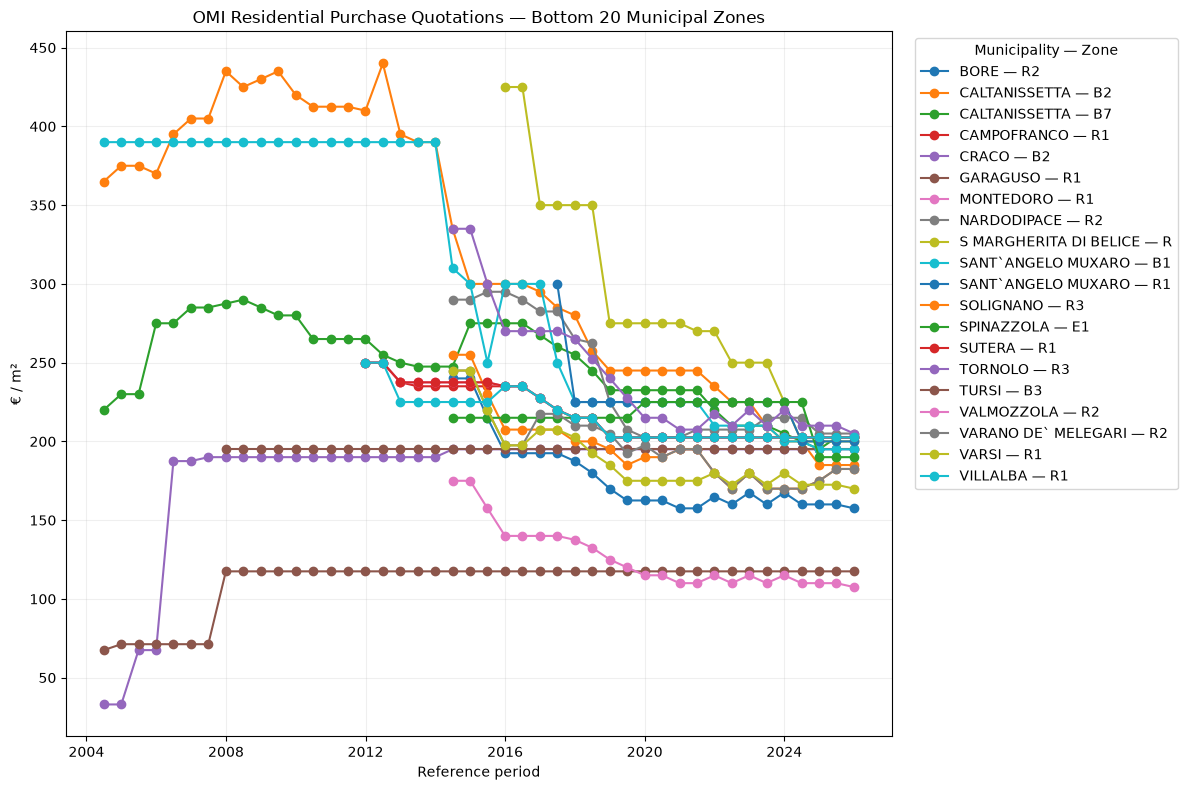

In [128]:
last_municipal_zones_names = (
    municipal_zone_trend[
        municipal_zone_trend['reference_date'].eq(latest_date)
    ]
    .nsmallest(20, 'median_compr_mid')
    [['Comune_descrizione', 'Zona']]
)

plot_data = municipal_zone_trend.merge(
    last_municipal_zones_names,
    on=['Comune_descrizione', 'Zona'],
    how='inner'
)

fig, ax = plt.subplots(figsize=(12, 8))

for (comune, zona), data in plot_data.groupby(
    ['Comune_descrizione', 'Zona']
):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.5,
        label=f'{comune} — {zona}'
    )

ax.set_title(
    'OMI Residential Purchase Quotations — Bottom 20 Municipal Zones'
)
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')

ax.grid(alpha=0.2)

ax.legend(
    title='Municipality — Zone',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

#### Focus Inspection

##### Lombardia - Provinces

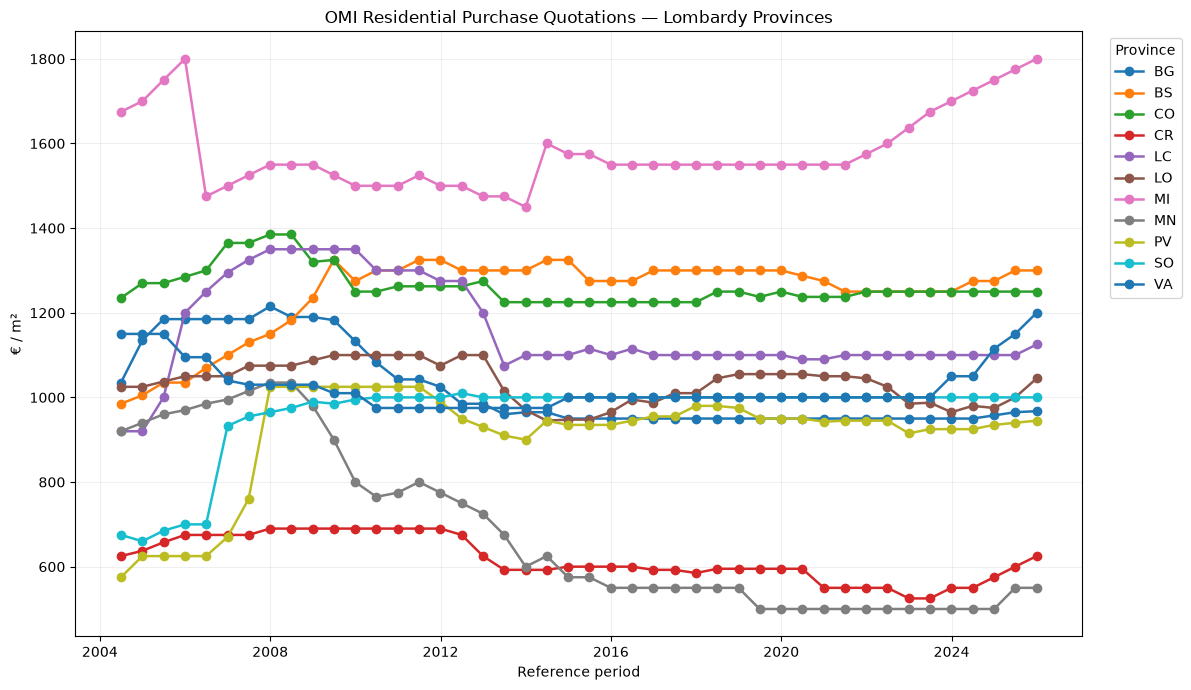

In [129]:
lombardia_trend = (
    residential[
        residential['Regione'].eq('LOMBARDIA')
    ]
    .groupby(
        ['reference_date', 'Prov'],
        as_index=False
    )
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        observations=('Compr_mid', 'count')
    )
)

fig, ax = plt.subplots(figsize=(12, 7))

for provincia, data in lombardia_trend.groupby('Prov'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        marker='o',
        linewidth=1.8,
        label=provincia
    )

ax.set_title('OMI Residential Purchase Quotations — Lombardy Provinces')
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Province',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()

plt.show()

##### Brescia - Municipialites

In [130]:
brescia_trend = (
    residential[
        residential['Prov'].eq('BS')
    ]
    .groupby(
        ['reference_date', 'Comune_descrizione'],
        as_index=False
    )
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = brescia_trend['reference_date'].max()

latest_brescia = (
    brescia_trend[
        brescia_trend['reference_date'].eq(latest_date)
    ]
    .sort_values('median_compr_mid', ascending=False)
)

top_10 = latest_brescia.head(10)['Comune_descrizione']

middle_10 = (
    latest_brescia
    .iloc[len(latest_brescia) // 2 - 5 : len(latest_brescia) // 2 + 5]
    ['Comune_descrizione']
)

last_10 = latest_brescia.tail(10)['Comune_descrizione']

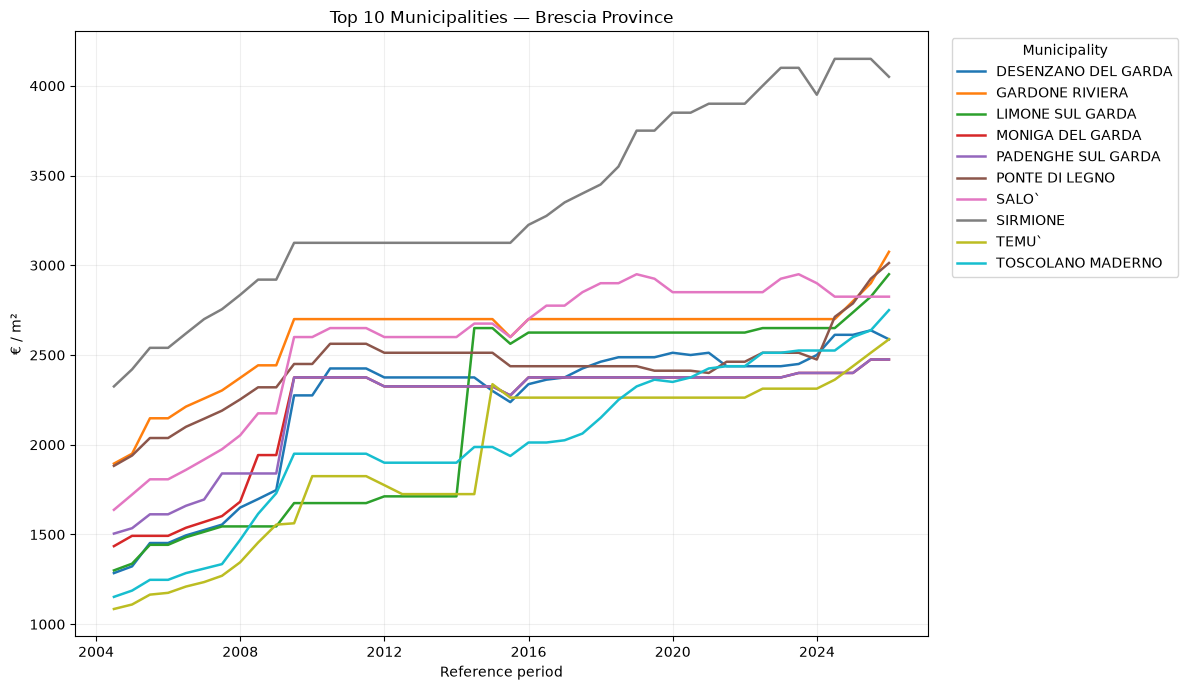

In [131]:
plot_data = brescia_trend[
    brescia_trend['Comune_descrizione'].isin(top_10)
]

fig, ax = plt.subplots(figsize=(12, 7))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        linewidth=1.8,
        label=comune
    )

ax.set_title(
    'Top 10 Municipalities — Brescia Province'
)
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Municipality',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

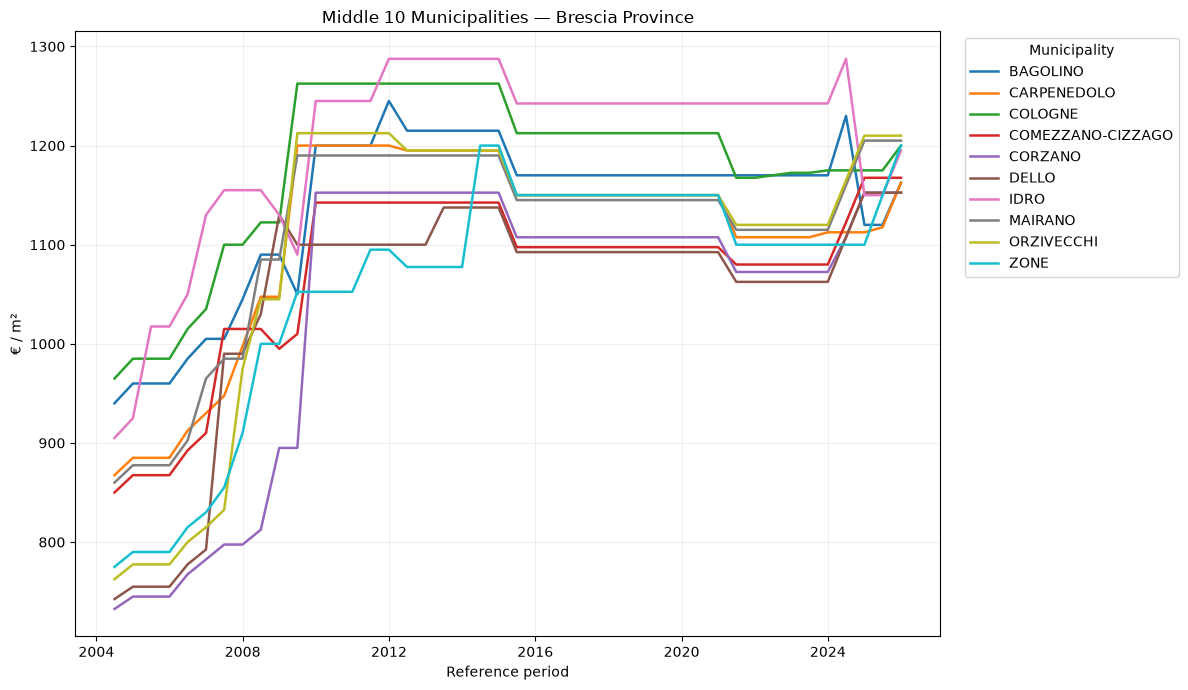

In [132]:
plot_data = brescia_trend[
    brescia_trend['Comune_descrizione'].isin(middle_10)
]

fig, ax = plt.subplots(figsize=(12, 7))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        linewidth=1.8,
        label=comune
    )

ax.set_title(
    'Middle 10 Municipalities — Brescia Province'
)
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Municipality',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

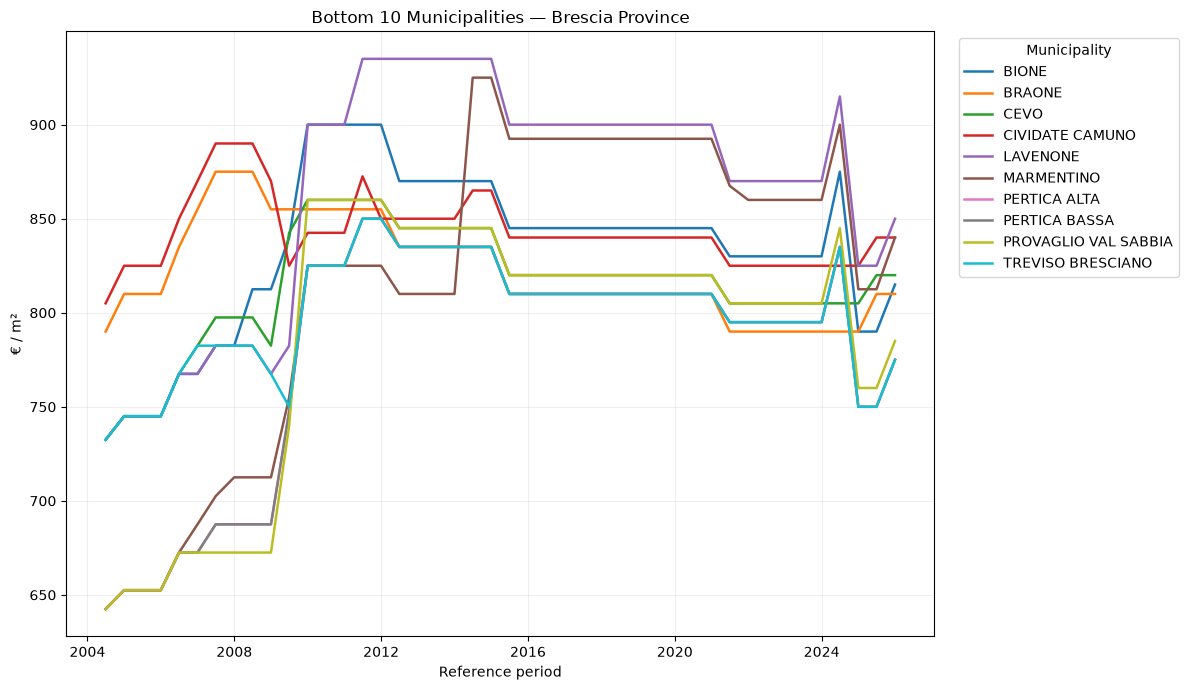

In [133]:
plot_data = brescia_trend[
    brescia_trend['Comune_descrizione'].isin(last_10)
]

fig, ax = plt.subplots(figsize=(12, 7))

for comune, data in plot_data.groupby('Comune_descrizione'):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        linewidth=1.8,
        label=comune
    )

ax.set_title(
    'Bottom 10 Municipalities — Brescia Province'
)
ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')
ax.grid(alpha=0.2)

ax.legend(
    title='Municipality',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

In [134]:
brescia_matrix = (
    residential[
        residential['Prov'].eq('BS')
    ]
    .assign(
        year=lambda x: x['reference_date'].dt.year
    )
    .groupby(
        ['Comune_descrizione', 'year'],
        as_index=False
    )
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        observations=('Compr_mid', 'count')
    )
)

# Matrice Comune × Anno
price_matrix = (
    brescia_matrix
    .pivot(
        index='Comune_descrizione',
        columns='year',
        values='median_compr_mid'
    )
)

# Classifica nell'ultimo anno disponibile
latest_year = price_matrix.columns.max()

ranking = (
    price_matrix[latest_year]
    .rank(
        method='min',
        ascending=False
    )
    .astype('Int64')
    .rename('rank_latest')
)

# Variazione percentuale tra primo e ultimo anno disponibile
first_year = price_matrix.columns.min()

change_pct = (
    (
        price_matrix[latest_year]
        / price_matrix[first_year]
        - 1
    ) * 100
).rename('change_pct')

# Tabella finale
brescia_matrix_final = (
    price_matrix
    .join(ranking)
    .join(change_pct)
    .sort_values('rank_latest')
)

brescia_matrix_final

,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,...,2018,2019,2020,2021,2022,2023,2024,2025,rank_latest,change_pct
Comune_descrizione,,,,,,,,,,,,,,,,,,,,,
SIRMIONE,2372.5,2540.0,2660.0,2795.0,2920.0,3125.0,3125.0,3125.0,3125.0,3125.0,...,3650.0,3800.0,3875.0,3900.0,4050.0,4025.0,4150.0,4100.0,1,72.813488
PONTE DI LEGNO,1910.0,2037.5,2122.5,2252.5,2320.0,2450.0,2562.5,2537.5,2512.5,2512.5,...,2437.5,2412.5,2400.0,2462.5,2512.5,2475.0,2750.0,2962.5,2,55.104712
GARDONE RIVIERA,1922.5,2147.5,2235.0,2337.5,2442.5,2700.0,2700.0,2700.0,2700.0,2700.0,...,2700.0,2700.0,2700.0,2700.0,2700.0,2700.0,2750.0,2950.0,3,53.446034
LIMONE SUL GARDA,1317.5,1442.5,1497.5,1545.0,1545.0,1675.0,1675.0,1687.5,1712.5,1712.5,...,2625.0,2625.0,2625.0,2625.0,2650.0,2650.0,2700.0,2875.0,4,118.216319
SALO`,1677.5,1807.5,1887.5,2012.5,2175.0,2600.0,2650.0,2650.0,2600.0,2600.0,...,2925.0,2887.5,2850.0,2850.0,2850.0,2925.0,2825.0,2825.0,5,68.405365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PERTICA BASSA,647.5,652.5,672.5,687.5,687.5,815.0,825.0,850.0,835.0,835.0,...,810.0,810.0,810.0,795.0,795.0,795.0,792.5,762.5,201,17.760618
LONATO,1022.5,1080.0,1132.5,1192.5,1320.0,1425.0,1450.0,1437.5,1425.0,1450.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
MAGASA,647.5,652.5,680.0,715.0,725.0,815.0,815.0,815.0,815.0,850.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN


In [135]:
observations_matrix = (
    brescia_matrix
    .pivot(
        index='Comune_descrizione',
        columns='year',
        values='observations'
    )
)

display(
    observations_matrix.style.format('{:,.0f}')
)

year,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Comune_descrizione,,,,,,,,,,,,,,,,,,,,,,
ACQUAFREDDA,4,4,3,2,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ADRO,10,10,9,8,8,11,14,14,14,14,8,8,8,8,8,8,8,8,8,8,8,8
AGNOSINE,4,4,3,2,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ALFIANELLO,4,4,3,2,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ANFO,4,4,3,2,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
ANGOLO TERME,4,4,4,4,4,6,8,8,8,8,6,6,6,6,6,6,6,6,6,6,6,6
ARTOGNE,6,6,6,6,6,9,12,12,12,12,9,8,8,8,8,8,8,8,8,8,8,8
AZZANO MELLA,4,4,3,2,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
BAGNOLO MELLA,6,6,6,6,9,12,12,12,12,12,8,8,8,8,8,8,8,8,8,8,8,8


In [136]:
summary = pd.DataFrame({
    'latest_price': price_matrix[latest_year],
    'rank_latest': ranking,
    'first_price': price_matrix[first_year],
    'change_pct': change_pct,
    'observations_latest': observations_matrix[latest_year]
})

summary = summary.sort_values('rank_latest')

display(
    summary.style.format({
        'latest_price': '€ {:,.0f}',
        'first_price': '€ {:,.0f}',
        'rank_latest': '{:.0f}',
        'change_pct': '{:+.1f}%',
        'observations_latest': '{:,.0f}'
    })
)

,latest_price,rank_latest,first_price,change_pct,observations_latest
Comune_descrizione,,,,,
SIRMIONE,"€ 4,100",1,"€ 2,372",+72.8%,18
PONTE DI LEGNO,"€ 2,962",2,"€ 1,910",+55.1%,24
GARDONE RIVIERA,"€ 2,950",3,"€ 1,922",+53.4%,22
LIMONE SUL GARDA,"€ 2,875",4,"€ 1,318",+118.2%,12
SALO`,"€ 2,825",5,"€ 1,678",+68.4%,18
TOSCOLANO MADERNO,"€ 2,688",6,"€ 1,170",+129.7%,12
DESENZANO DEL GARDA,"€ 2,588",7,"€ 1,302",+98.7%,28
TEMU`,"€ 2,550",8,"€ 1,090",+133.9%,12
PADENGHE SUL GARDA,"€ 2,475",9,"€ 1,520",+62.8%,18


##### Brescia - Muncipialitites - Zone

In [137]:
brescia_zone_trend = (
    residential[
        residential['Prov'].eq('BS')
    ]
    .groupby(
        ['reference_date', 'Comune_descrizione', 'Zona'],
        as_index=False
    )
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        observations=('Compr_mid', 'count')
    )
)

latest_date = brescia_zone_trend['reference_date'].max()

latest_brescia_zones = (
    brescia_zone_trend[
        brescia_zone_trend['reference_date'].eq(latest_date)
    ]
    .sort_values('median_compr_mid', ascending=False)
)

top_10 = (
    latest_brescia_zones
    .head(10)[['Comune_descrizione', 'Zona']]
)

middle_10 = (
    latest_brescia_zones
    .iloc[
        len(latest_brescia_zones) // 2 - 5 :
        len(latest_brescia_zones) // 2 + 5
    ][['Comune_descrizione', 'Zona']]
)

last_10 = (
    latest_brescia_zones
    .tail(10)[['Comune_descrizione', 'Zona']]
)

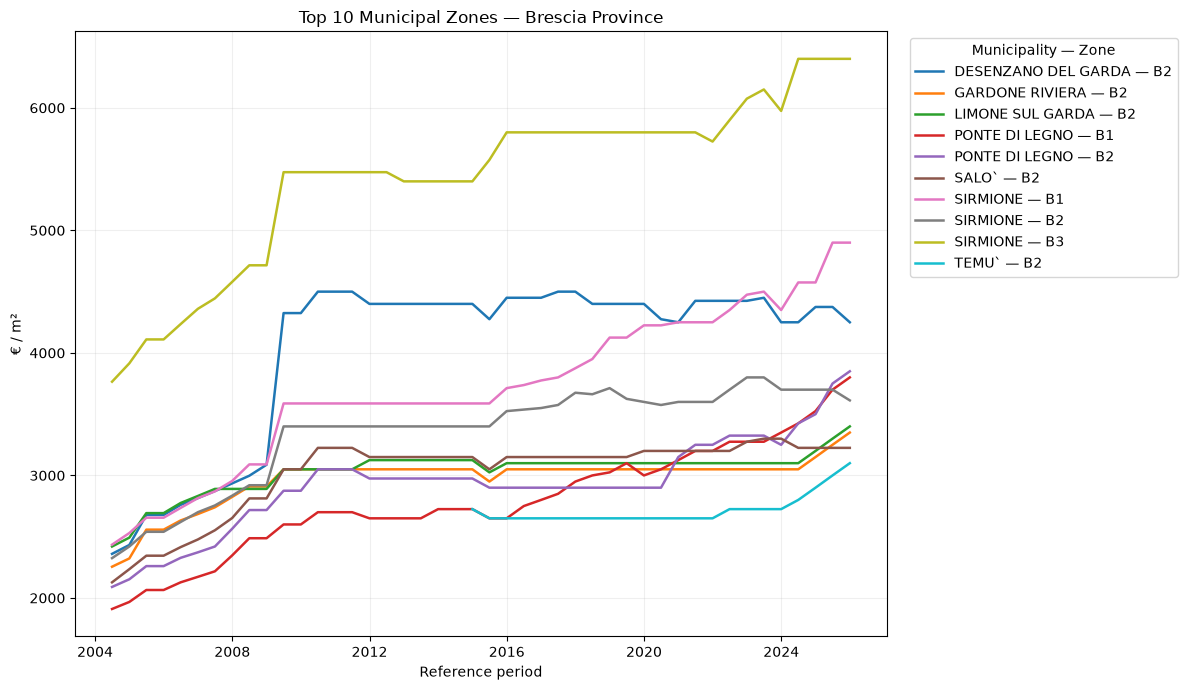

In [138]:
plot_data = brescia_zone_trend.merge(
    top_10,
    on=['Comune_descrizione', 'Zona'],
    how='inner'
)

fig, ax = plt.subplots(figsize=(12, 7))

for (comune, zona), data in plot_data.groupby(
    ['Comune_descrizione', 'Zona']
):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        linewidth=1.8,
        label=f'{comune} — {zona}'
    )

ax.set_title(
    'Top 10 Municipal Zones — Brescia Province'
)

ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')

ax.grid(alpha=0.2)

ax.legend(
    title='Municipality — Zone',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

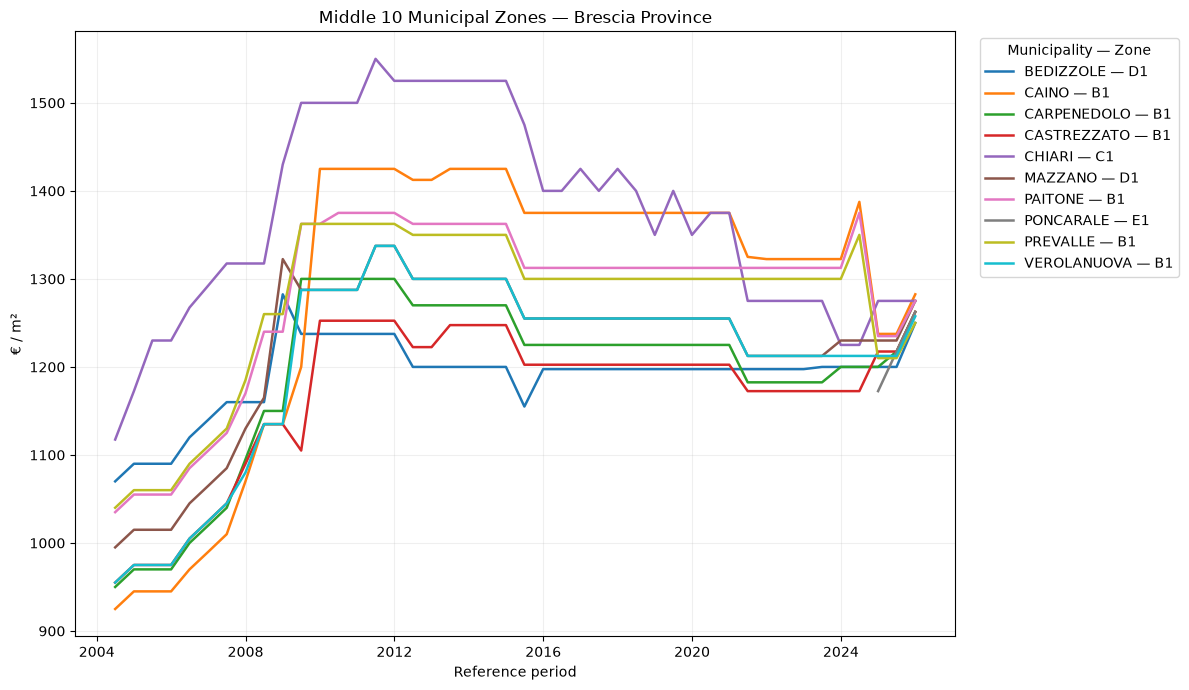

In [139]:
plot_data = brescia_zone_trend.merge(
    middle_10,
    on=['Comune_descrizione', 'Zona'],
    how='inner'
)

fig, ax = plt.subplots(figsize=(12, 7))

for (comune, zona), data in plot_data.groupby(
    ['Comune_descrizione', 'Zona']
):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        linewidth=1.8,
        label=f'{comune} — {zona}'
    )

ax.set_title(
    'Middle 10 Municipal Zones — Brescia Province'
)

ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')

ax.grid(alpha=0.2)

ax.legend(
    title='Municipality — Zone',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

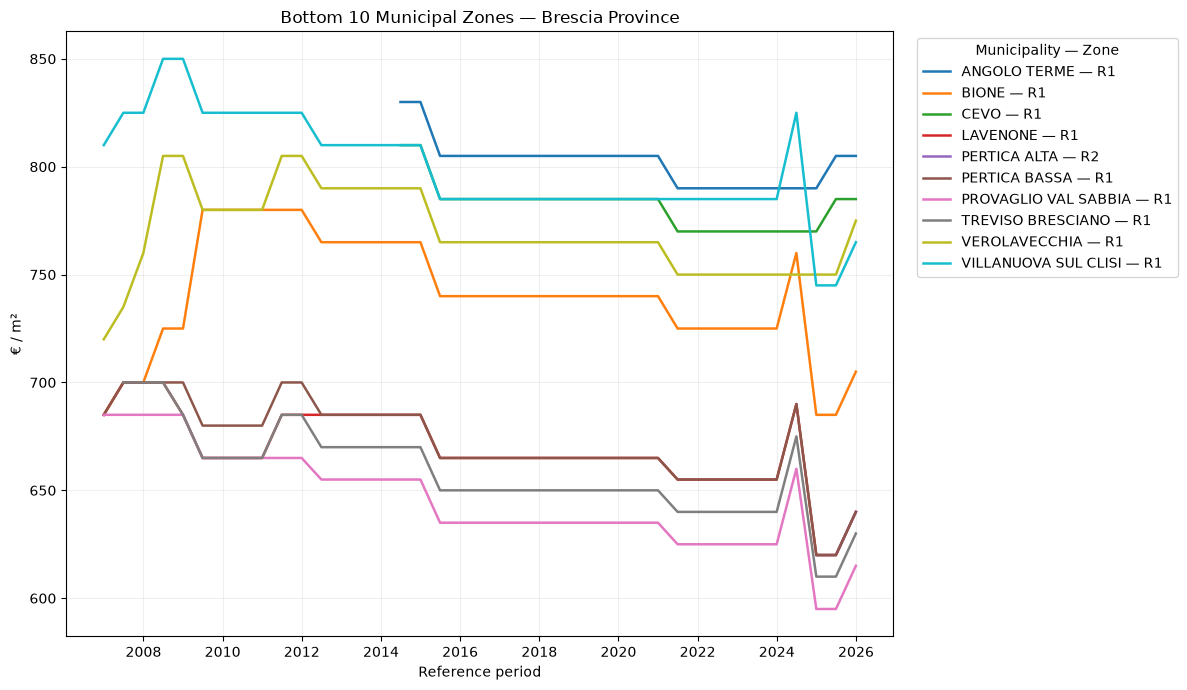

In [140]:
plot_data = brescia_zone_trend.merge(
    last_10,
    on=['Comune_descrizione', 'Zona'],
    how='inner'
)

fig, ax = plt.subplots(figsize=(12, 7))

for (comune, zona), data in plot_data.groupby(
    ['Comune_descrizione', 'Zona']
):
    ax.plot(
        data['reference_date'],
        data['median_compr_mid'],
        linewidth=1.8,
        label=f'{comune} — {zona}'
    )

ax.set_title(
    'Bottom 10 Municipal Zones — Brescia Province'
)

ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')

ax.grid(alpha=0.2)

ax.legend(
    title='Municipality — Zone',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

fig.tight_layout()
plt.show()

##### Total Municipalitiets - Zone - inspection

In [141]:
national_zone_trend = (
    residential
    .groupby(
        ['reference_date', 'Comune_descrizione', 'Zona'],
        as_index=False
    )
    .agg(
        median_compr_mid=('Compr_mid', 'median'),
        mean_compr_mid=('Compr_mid', 'mean'),
        observations=('Compr_mid', 'count')
    )
    .sort_values(
        ['Comune_descrizione', 'Zona', 'reference_date']
    )
)

# Semester label
national_zone_trend['period'] = (
    national_zone_trend['reference_date'].dt.year.astype(str)
    + '-S'
    + national_zone_trend['reference_date']
    .dt.month
    .map({6: 1, 12: 2})
    .astype(str)
)

# Semester-over-semester growth
national_zone_trend['growth_pct'] = (
    national_zone_trend
    .groupby(
        ['Comune_descrizione', 'Zona']
    )['median_compr_mid']
    .pct_change()
    .mul(100)
)

# Year-over-year growth
national_zone_trend['yoy_growth_pct'] = (
    national_zone_trend
    .groupby(
        ['Comune_descrizione', 'Zona']
    )['median_compr_mid']
    .pct_change(2)
    .mul(100)
)

# Rolling maximum price
national_zone_trend['rolling_max'] = (
    national_zone_trend
    .groupby(
        ['Comune_descrizione', 'Zona']
    )['median_compr_mid']
    .cummax()
)

# Drawdown from previous maximum
national_zone_trend['drawdown_pct'] = (
    (
        national_zone_trend['median_compr_mid']
        / national_zone_trend['rolling_max']
    ) - 1
) * 100

In [142]:
national_zone_trend

,reference_date,Comune_descrizione,Zona,median_compr_mid,mean_compr_mid,observations,period,growth_pct,yoy_growth_pct,rolling_max,drawdown_pct
0,2004-06-30,ABANO TERME,B1,1277.5,1277.5,2,2004-S1,NaN,NaN,1277.5,0.000000
25482,2004-12-31,ABANO TERME,B1,1355.0,1355.0,2,2004-S2,6.066536,NaN,1355.0,0.000000
51166,2005-06-30,ABANO TERME,B1,1355.0,1355.0,2,2005-S1,0.000000,6.066536,1355.0,0.000000
76621,2005-12-31,ABANO TERME,B1,1330.0,1330.0,2,2005-S2,-1.845018,-1.845018,1355.0,-1.845018
102269,2006-06-30,ABANO TERME,B1,1330.0,1330.0,2,2006-S1,0.000000,-1.845018,1355.0,-1.845018
...,...,...,...,...,...,...,...,...,...,...,...
975153,2023-12-31,ZUNGRI,R2,275.0,275.0,1,2023-S2,0.000000,2.803738,295.0,-6.779661
998242,2024-06-30,ZUNGRI,R2,275.0,275.0,1,2024-S1,0.000000,0.000000,295.0,-6.779661
1021121,2024-12-31,ZUNGRI,R2,275.0,275.0,1,2024-S2,0.000000,0.000000,295.0,-6.779661
1044000,2025-06-30,ZUNGRI,R2,277.5,277.5,1,2025-S1,0.909091,0.909091,295.0,-5.932203


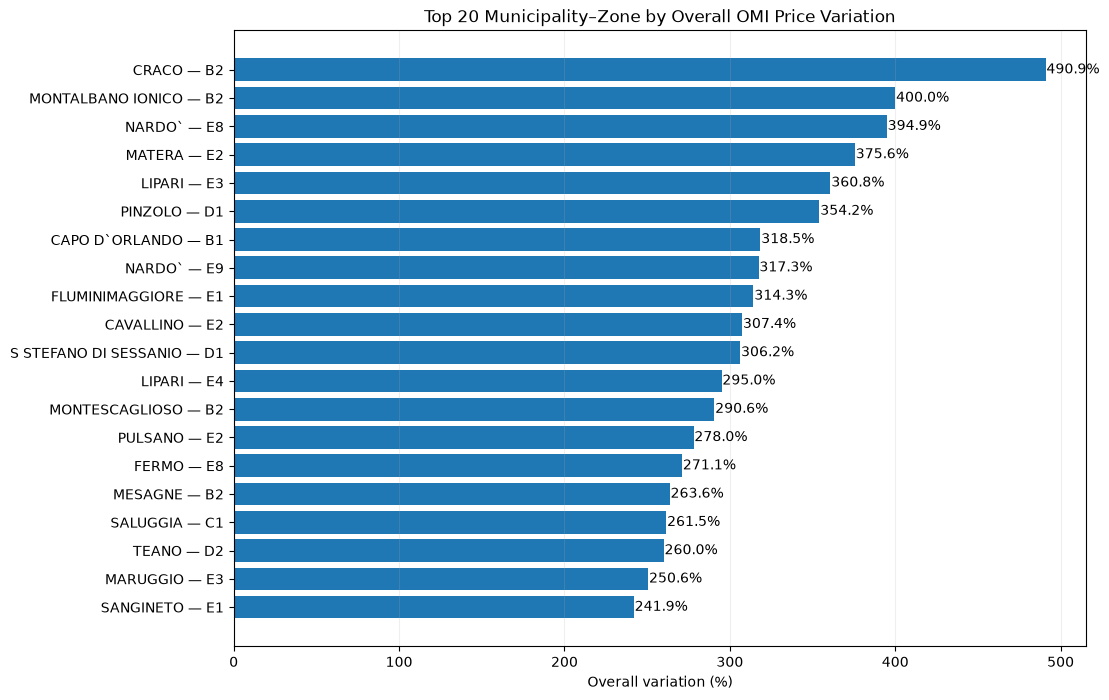

In [143]:
overall_change = (
    national_zone_trend
    .groupby(
        ['Comune_descrizione', 'Zona']
    )
    .agg(
        first_price=('median_compr_mid', 'first'),
        last_price=('median_compr_mid', 'last'),
        first_date=('reference_date', 'first'),
        last_date=('reference_date', 'last')
    )
)

overall_change['overall_change_pct'] = (
    (
        overall_change['last_price']
        / overall_change['first_price']
    ) - 1
) * 100

top_growth = (
    overall_change
    .nlargest(20, 'overall_change_pct')
    .reset_index()
    .sort_values('overall_change_pct')
)

fig, ax = plt.subplots(figsize=(11, 8))

labels = (
    top_growth['Comune_descrizione']
    + ' — '
    + top_growth['Zona']
)

bars = ax.barh(
    labels,
    top_growth['overall_change_pct']
)

for bar, value in zip(
    bars,
    top_growth['overall_change_pct']
):
    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center'
    )

ax.set_title(
    'Top 20 Municipality–Zone by Overall OMI Price Variation'
)

ax.set_xlabel('Overall variation (%)')
ax.set_ylabel('')

ax.grid(
    axis='x',
    alpha=0.2
)

plt.show()

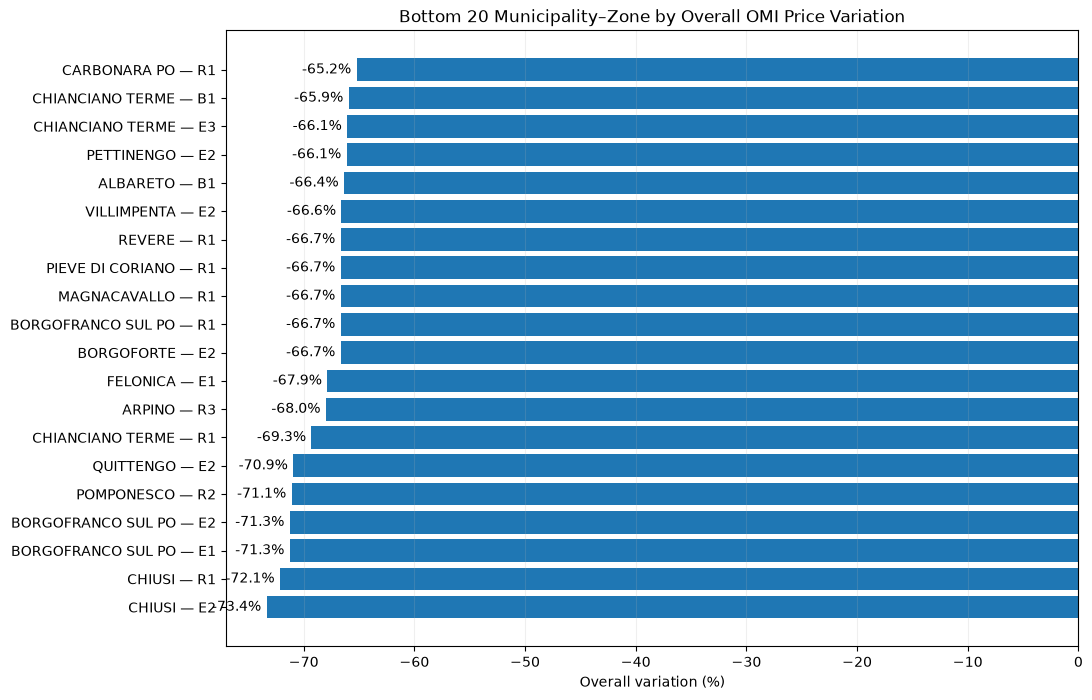

In [144]:
bottom_growth = (
    overall_change
    .nsmallest(20, 'overall_change_pct')
    .reset_index()
    .sort_values('overall_change_pct')
)

fig, ax = plt.subplots(figsize=(11, 8))

labels = (
    bottom_growth['Comune_descrizione']
    + ' — '
    + bottom_growth['Zona']
)

bars = ax.barh(
    labels,
    bottom_growth['overall_change_pct']
)

for bar, value in zip(
    bars,
    bottom_growth['overall_change_pct']
):
    ax.text(
        value - 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center',
        ha='right'
    )

ax.set_title(
    'Bottom 20 Municipality–Zone by Overall OMI Price Variation'
)

ax.set_xlabel('Overall variation (%)')
ax.set_ylabel('')

ax.grid(
    axis='x',
    alpha=0.2
)

plt.show()

In [145]:
# Municipality–Zone summary metrics

summary_matrix = (
    national_zone_trend
    .groupby(
        ['Comune_descrizione', 'Zona']
    )
    .agg(
        first_price=('median_compr_mid', 'first'),
        last_price=('median_compr_mid', 'last'),
        first_date=('reference_date', 'first'),
        last_date=('reference_date', 'last'),
        mean_growth_pct=('growth_pct', 'mean'),
        growth_volatility=('growth_pct', 'std'),
        positive_periods=('growth_pct', lambda x: (x > 0).sum()),
        negative_periods=('growth_pct', lambda x: (x < 0).sum()),
        max_drawdown_pct=('drawdown_pct', 'min'),
        max_price=('median_compr_mid', 'max'),
        min_price=('median_compr_mid', 'min'),
        total_observations=('observations', 'sum'),
        n_periods=('reference_date', 'count')
    )
)

# Coverage in years
summary_matrix['coverage_years'] = (
    (
        summary_matrix['last_date']
        - summary_matrix['first_date']
    ).dt.days / 365.25
)

# Overall price variation
summary_matrix['overall_change_pct'] = (
    (
        summary_matrix['last_price']
        / summary_matrix['first_price']
    ) - 1
) * 100

# Absolute price variation
summary_matrix['absolute_change_eur_m2'] = (
    summary_matrix['last_price']
    - summary_matrix['first_price']
)

# CAGR
summary_matrix['cagr_pct'] = (
    (
        summary_matrix['last_price']
        / summary_matrix['first_price']
    ) ** (
        1 / summary_matrix['coverage_years']
    ) - 1
) * 100

# Latest YoY growth
latest_yoy = (
    national_zone_trend
    .sort_values('reference_date')
    .groupby(
        ['Comune_descrizione', 'Zona']
    )['yoy_growth_pct']
    .last()
)

summary_matrix['latest_yoy_growth_pct'] = latest_yoy

# Share of positive-growth periods
summary_matrix['positive_growth_share_pct'] = (
    summary_matrix['positive_periods']
    / (
        summary_matrix['positive_periods']
        + summary_matrix['negative_periods']
    )
) * 100

# Latest drawdown from historical maximum
latest_drawdown = (
    national_zone_trend
    .sort_values('reference_date')
    .groupby(
        ['Comune_descrizione', 'Zona']
    )['drawdown_pct']
    .last()
)

summary_matrix['latest_drawdown_pct'] = latest_drawdown

# Price range
summary_matrix['price_range_eur_m2'] = (
    summary_matrix['max_price']
    - summary_matrix['min_price']
)

summary_matrix['price_range_pct'] = (
    (
        summary_matrix['max_price']
        / summary_matrix['min_price']
    ) - 1
) * 100

# Sort by overall variation
summary_matrix = (
    summary_matrix
    .sort_values(
        'overall_change_pct',
        ascending=False
    )
)

display(
    summary_matrix.head(20)
)

,,first_price,last_price,first_date,last_date,mean_growth_pct,growth_volatility,positive_periods,negative_periods,max_drawdown_pct,max_price,...,n_periods,coverage_years,overall_change_pct,absolute_change_eur_m2,cagr_pct,latest_yoy_growth_pct,positive_growth_share_pct,latest_drawdown_pct,price_range_eur_m2,price_range_pct
Comune_descrizione,Zona,,,,,,,,,,,,,,,,,,,,,
CRACO,B2,33.0,195.00,2004-06-30,2025-12-31,6.657864,31.105552,4,0,0.000000,195.00,...,44,21.503080,490.909091,162.00,8.612433,0.000000,100.000000,0.000000,162.00,490.909091
MONTALBANO IONICO,B2,69.0,345.00,2004-06-30,2025-12-31,9.261915,60.666345,3,0,0.000000,345.00,...,44,21.503080,400.000000,276.00,7.771909,0.000000,100.000000,0.000000,276.00,400.000000
NARDO`,E8,245.0,1212.50,2004-06-30,2025-12-31,15.831710,76.636575,8,3,-5.319149,1212.50,...,25,21.503080,394.897959,967.50,7.720516,2.320675,72.727273,0.000000,967.50,394.897959
MATERA,E2,287.0,1365.00,2004-06-30,2025-12-31,4.849115,18.275191,8,2,-18.294574,1612.50,...,44,21.503080,375.609756,1078.00,7.521552,0.000000,80.000000,-15.348837,1325.50,461.846690
LIPARI,E3,415.0,1912.50,2004-06-30,2025-12-31,4.577613,17.078909,13,3,-12.307692,1912.50,...,44,21.503080,360.843373,1497.50,7.363961,11.678832,81.250000,0.000000,1497.50,360.843373
PINZOLO,D1,600.0,2725.00,2004-06-30,2007-06-30,51.231560,118.063127,3,0,0.000000,2725.00,...,7,2.997947,354.166667,2125.00,65.661581,0.000000,100.000000,0.000000,2125.00,354.166667
CAPO D`ORLANDO,B1,460.0,1925.00,2004-06-30,2025-12-31,4.078493,13.784081,19,7,-17.241379,1925.00,...,44,21.503080,318.478261,1465.00,6.883552,10.000000,73.076923,0.000000,1465.00,318.478261
NARDO`,E9,245.0,1022.50,2004-06-30,2025-12-31,14.642162,73.659039,8,5,-14.634146,1127.50,...,25,21.503080,317.346939,777.50,6.870097,0.738916,61.538462,-9.312639,882.50,360.204082
FLUMINIMAGGIORE,E1,350.0,1450.00,2004-06-30,2025-12-31,6.690855,42.221748,3,2,-9.375000,1600.00,...,44,21.503080,314.285714,1100.00,6.833514,0.000000,60.000000,-9.375000,1250.00,357.142857


In [146]:
summary_matrix.nlargest(20, 'cagr_pct')

first_price  last_price first_date  last_date  \
Comune_descrizione Zona                                                  
SAN VITO LO CAPO   B2          750.0      1235.0 2004-06-30 2004-12-31   
NAPOLI             E9         1750.0      2570.0 2004-06-30 2004-12-31   
TAGGIA             E1          780.0      1425.0 2004-06-30 2005-06-30   
ORTA DI ATELLA     D1          800.0      1450.0 2005-06-30 2006-06-30   
VITTORIA           D8          425.0       560.0 2004-06-30 2004-12-31   
POZZALLO           B2          325.0       425.0 2004-06-30 2004-12-31   
PINZOLO            D1          600.0      2725.0 2004-06-30 2007-06-30   
RAGUSA             E5          790.0      1012.5 2004-06-30 2004-12-31   
                   D7          482.5       617.5 2004-06-30 2004-12-31   
VITERBO            B2         1005.0      1600.0 2004-06-30 2005-06-30   
                   B5         1005.0      1600.0 2004-06-30 2005-06-30   
                   B3         1005.0      1600.0 2004-06-30 2005-06-30   
                   B4         1005.0      1600.0 2004-06-30 2005-06-30   
                   B1         1005.0      1600.0 2004-06-30 2005-06-30   
ORTA DI ATELLA     D2          975.0      1550.0 2005-06-30 2006-06-30   
VITULAZIO          E1          700.0       860.0 2012-06-30 2012-12-31   
SCICLI             E3          555.0       680.0 2004-06-30 2004-12-31   
ORVIETO            C1          917.5      1115.0 2004-06-30 2004-12-31   
VAIRANO PATENORA   B2          465.0      1000.0 2004-06-30 2006-06-30   
CUPRA MARITTIMA    E1          812.5       970.0 2004-06-30 2004-12-31   

                         mean_growth_pct  growth_volatility  positive_periods  \
Comune_descrizione Zona                                                         
SAN VITO LO CAPO   B2          64.666667                NaN                 1   
NAPOLI             E9          46.857143                NaN                 1   
TAGGIA             E1          41.346154          58.472292                 1   
ORTA DI ATELLA     D1          35.000000          14.142136                 2   
VITTORIA           D8          31.764706                NaN                 1   
POZZALLO           B2          30.769231                NaN                 1   
PINZOLO            D1          51.231560         118.063127                 3   
RAGUSA             E5          28.164557                NaN                 1   
                   D7          27.979275                NaN                 1   
VITERBO            B2          27.081260          21.412554                 2   
                   B5          27.081260          21.412554                 2   
                   B3          27.081260          21.412554                 2   
                   B4          27.081260          21.412554                 2   
                   B1          27.081260          21.412554                 2   
ORTA DI ATELLA     D2          26.365663          11.903358                 2   
VITULAZIO          E1          22.857143                NaN                 1   
SCICLI             E3          22.522523                NaN                 1   
ORVIETO            C1          21.525886                NaN                 1   
VAIRANO PATENORA   B2          23.944030          32.694603                 3   
CUPRA MARITTIMA    E1          19.384615                NaN                 1   

                         negative_periods  max_drawdown_pct  max_price  ...  \
Comune_descrizione Zona                                                 ...   
SAN VITO LO CAPO   B2                   0               0.0     1235.0  ...   
NAPOLI             E9                   0               0.0     2570.0  ...   
TAGGIA             E1                   0               0.0     1425.0  ...   
ORTA DI ATELLA     D1                   0               0.0     1450.0  ...   
VITTORIA           D8                   0               0.0      560.0  ...   
POZZALLO           B2                   0               0.0 

In [147]:
summary_matrix.nlargest(20, 'growth_volatility')

first_price  last_price first_date  last_date  \
Comune_descrizione  Zona                                                  
PINZOLO             D1          600.0     2725.00 2004-06-30 2007-06-30   
NARDO`              E8          245.0     1212.50 2004-06-30 2025-12-31   
                    E9          245.0     1022.50 2004-06-30 2025-12-31   
SALUGGIA            C1          292.5     1057.50 2004-06-30 2013-12-31   
MONTALBANO IONICO   B2           69.0      345.00 2004-06-30 2025-12-31   
TAGGIA              E1          780.0     1425.00 2004-06-30 2005-06-30   
BARBARANO VICENTINO C2          725.0     1300.00 2011-12-31 2013-12-31   
ISILI               E2          270.0      600.00 2004-06-30 2006-12-31   
SALUGGIA            D1          292.5      920.00 2004-06-30 2013-12-31   
FERMO               E8          640.0     2375.00 2004-12-31 2025-12-31   
LIZZANELLO          E2          230.0      773.75 2004-06-30 2025-12-31   
ELINI               E2          235.0      485.00 2004-06-30 2006-12-31   
OLLOLAI             E2          235.0      485.00 2004-06-30 2006-12-31   
ORANI               E2          235.0      485.00 2004-06-30 2006-12-31   
DESULO              E2          235.0      485.00 2004-06-30 2006-12-31   
LIPARI              E4          595.0     2350.00 2004-06-30 2025-12-31   
AMANTEA             D1          325.0     1052.50 2004-06-30 2013-12-31   
PRAROLO             E1          340.0      955.00 2004-06-30 2013-12-31   
OVODDA              E2          245.0      485.00 2004-06-30 2006-12-31   
OROTELLI            E2          245.0      485.00 2004-06-30 2006-12-31   

                          mean_growth_pct  growth_volatility  \
Comune_descrizione  Zona                                       
PINZOLO             D1          51.231560         118.063127   
NARDO`              E8          15.831710          76.636575   
                    E9          14.642162          73.659039   
SALUGGIA            C1          15.279307          68.978459   
MONTALBANO IONICO   B2           9.261915          60.666345   
TAGGIA              E1          41.346154          58.472292   
BARBARANO VICENTINO C2          23.159443          55.465623   
ISILI               E2          24.444444          54.659439   
SALUGGIA            D1          11.793158          52.418545   
FERMO               E8           7.918340          52.158270   
LIZZANELLO          E2          10.123296          49.838925   
ELINI               E2          21.276596          47.575914   
OLLOLAI             E2          21.276596          47.575914   
ORANI               E2          21.276596          47.575914   
DESULO              E2          21.276596          47.575914   
LIPARI              E4           7.099397          46.934883   
AMANTEA             D1          11.820360          45.642713   
PRAROLO             E1           9.979876          44.602909   
OVODDA              E2          19.591837          43.808679   
OROTELLI            E2          19.591837          43.808679   

                          positive_periods  negative_periods  \
Comune_descrizione  Zona                                       
PINZOLO             D1                   3                 0   
NARDO`              E8                   8                 3   
                    E9                   8                 5   
SALUGGIA            C1                   3                 3   
MONTALBANO IONICO   B2                   3                 0   
TAGGIA              E1                   1                 0   
BARBARANO VICENTINO C2                   1                 3   
ISILI               E2                   1                 0   
SALUGGIA            D1                   2                 2   
FERMO               E8                   5                 6   
LIZZANELLO          E2                  12                11   
ELINI               E2                   1                 0   
OLLOLAI             E2                   1                 0   
ORANI 

In [148]:
summary_matrix.nsmallest(20, 'max_drawdown_pct')

first_price  last_price first_date  last_date  \
Comune_descrizione     Zona                                                  
CHIUSI                 E2         1600.0      426.25 2004-06-30 2025-12-31   
BORGOFRANCO SUL PO     R1         1087.5      362.50 2008-06-30 2018-12-31   
MAGNACAVALLO           R1         1087.5      362.50 2008-06-30 2025-12-31   
CHIUSI                 R1         1467.5      408.75 2004-06-30 2025-12-31   
PIEVE DI CORIANO       R1         1087.5      362.50 2008-06-30 2017-12-31   
REVERE                 R1         1087.5      362.50 2008-06-30 2017-12-31   
BORGOFRANCO SUL PO     E2         1087.5      312.50 2008-06-30 2013-12-31   
                       E1         1087.5      312.50 2008-06-30 2013-12-31   
POMPONESCO             R2          865.0      250.00 2008-06-30 2013-12-31   
QUITTENGO              E2          895.0      260.00 2004-06-30 2013-12-31   
QUINGENTOLE            R1         1042.5      400.00 2008-06-30 2025-12-31   
SAN GIACOMO D SEGNATE  R1         1042.5      362.50 2008-06-30 2025-12-31   
SAN GIOVANNI DEL DOSSO R1         1042.5      362.50 2008-06-30 2025-12-31   
VILLA POMA             R1         1042.5      362.50 2008-06-30 2017-12-31   
SCHIVENOGLIA           R1         1042.5      362.50 2008-06-30 2025-12-31   
CARBONARA PO           R1         1042.5      362.50 2008-06-30 2018-12-31   
SAN TEODORO            B1          725.0      421.25 2004-06-30 2025-12-31   
POGGIO RUSCO           R1         1025.0      412.50 2008-06-30 2025-12-31   
CHIANCIANO TERME       R1         1787.5      548.75 2004-06-30 2025-12-31   
FABRIANO               B1         1485.0      550.00 2004-06-30 2025-12-31   

                             mean_growth_pct  growth_volatility  \
Comune_descrizione     Zona                                       
CHIUSI                 E2          -2.810625           6.378720   
BORGOFRANCO SUL PO     R1          -4.448854          10.841626   
MAGNACAVALLO           R1          -2.653840           8.769065   
CHIUSI                 R1          -2.741595           5.964270   
PIEVE DI CORIANO       R1          -4.990053          10.562776   
REVERE                 R1          -4.990053          10.562776   
BORGOFRANCO SUL PO     E2          -9.558819          13.779255   
                       E1          -9.649169          13.671380   
POMPONESCO             R2          -9.455587          13.828568   
QUITTENGO              E2          -3.872160          15.983802   
QUINGENTOLE            R1          -2.338153           8.031257   
SAN GIACOMO D SEGNATE  R1          -2.633719           7.735686   
SAN GIOVANNI DEL DOSSO R1          -2.633719           7.735686   
VILLA POMA             R1          -4.851589          10.083388   
SCHIVENOGLIA           R1          -2.633719           7.735686   
CARBONARA PO           R1          -4.389532           9.676614   
SAN TEODORO            B1          -0.276983          15.738058   
POGGIO RUSCO           R1          -2.207098           8.086866   
CHIANCIANO TERME       R1          -2.322983           8.912560   
FABRIANO               B1          -2.178531           4.618420   

                             positive_periods  negative_periods  \
Comune_descrizione     Zona                                       
CHIUSI                 E2                   6                18   
BORGOFRANCO SUL PO     R1                   2                10   
MAGNACAVALLO           R1                   3                 9   
CHIUSI                 R1                   6                18   
PIEVE DI CORIANO       R1                   2                10   
REVERE                 R1                   2                10   
BORGOFRANCO SUL PO     E2                   2                 9   
                       E1                   2                 8   
POMPONESCO             R2                   1                 8   
QUITTENGO              E2                   0                 3   
QUINGENTOLE            R1        

In [149]:
summary_matrix.nlargest(
    20,
    'positive_growth_share_pct'
)

,,first_price,last_price,first_date,last_date,mean_growth_pct,growth_volatility,positive_periods,negative_periods,max_drawdown_pct,max_price,...,n_periods,coverage_years,overall_change_pct,absolute_change_eur_m2,cagr_pct,latest_yoy_growth_pct,positive_growth_share_pct,latest_drawdown_pct,price_range_eur_m2,price_range_pct
Comune_descrizione,Zona,,,,,,,,,,,,,,,,,,,,,
CRACO,B2,33.0,195.00,2004-06-30,2025-12-31,6.657864,31.105552,4,0,0.0,195.00,...,44,21.503080,490.909091,162.00,8.612433,0.000000,100.0,0.0,162.00,490.909091
MONTALBANO IONICO,B2,69.0,345.00,2004-06-30,2025-12-31,9.261915,60.666345,3,0,0.0,345.00,...,44,21.503080,400.000000,276.00,7.771909,0.000000,100.0,0.0,276.00,400.000000
PINZOLO,D1,600.0,2725.00,2004-06-30,2007-06-30,51.231560,118.063127,3,0,0.0,2725.00,...,7,2.997947,354.166667,2125.00,65.661581,0.000000,100.0,0.0,2125.00,354.166667
MONTESCAGLIOSO,B2,56.0,218.75,2004-06-30,2025-12-31,5.821780,35.671966,3,0,0.0,218.75,...,44,21.503080,290.625000,162.75,6.541739,0.000000,100.0,0.0,162.75,290.625000
MESAGNE,B2,165.0,600.00,2004-06-30,2025-12-31,4.868651,27.926271,5,0,0.0,600.00,...,44,21.503080,263.636364,435.00,6.187602,0.000000,100.0,0.0,435.00,263.636364
BADOLATO,E1,155.0,500.00,2004-06-30,2013-12-31,8.606504,27.407601,2,0,0.0,500.00,...,20,9.503080,222.580645,345.00,13.115865,0.000000,100.0,0.0,345.00,222.580645
SANTA MARINA SALINA,D1,710.0,2200.00,2004-06-30,2013-12-31,10.312422,43.223287,3,0,0.0,2200.00,...,20,9.503080,209.859155,1490.00,12.637954,0.000000,100.0,0.0,1490.00,209.859155
IGLESIAS,E1,425.0,1300.00,2004-06-30,2013-12-31,6.527319,10.684225,7,0,0.0,1300.00,...,20,9.503080,205.882353,875.00,12.484952,0.000000,100.0,0.0,875.00,205.882353
MALFA,E1,850.0,2537.50,2014-06-30,2025-12-31,8.093091,37.358735,3,0,0.0,2537.50,...,24,11.504449,198.529412,1687.50,9.973300,3.571429,100.0,0.0,1687.50,198.529412


In [150]:
summary_matrix.nlargest(
    20,
    'latest_yoy_growth_pct'
)

first_price  last_price first_date  last_date  \
Comune_descrizione Zona                                                  
SAN NAZARIO        D1          570.0      1250.0 2004-12-31 2013-12-31   
                   C1          570.0      1250.0 2004-06-30 2013-12-31   
TONEZZA DEL CIMONE D1          570.0      1250.0 2004-06-30 2013-12-31   
CISMON DEL GRAPPA  C1          570.0      1250.0 2004-06-30 2013-12-31   
ROTZO              D1          675.0      1450.0 2004-06-30 2013-12-31   
CHIAMPO            D1          665.0      1400.0 2004-06-30 2013-12-31   
SAN PIER NICETO    D1          325.0       812.5 2004-06-30 2014-06-30   
CISMON DEL GRAPPA  D1          550.0      1200.0 2004-06-30 2013-12-31   
VALSTAGNA          C1          570.0      1250.0 2004-06-30 2013-12-31   
BREGANZE           C1          695.0      1450.0 2004-06-30 2013-12-31   
TRISSINO           D2          675.0      1350.0 2004-12-31 2013-12-31   
SOLAGNA            D1          570.0      1200.0 2004-06-30 2013-12-31   
CHIAMPO            D3          695.0      1400.0 2004-06-30 2013-12-31   
                   D2          695.0      1400.0 2004-06-30 2013-12-31   
ROCCAMASSIMA       E1          550.0      1025.0 2004-06-30 2013-12-31   
VALSTAGNA          D1          575.0      1200.0 2004-12-31 2013-12-31   
SARCEDO            D2          685.0      1350.0 2004-12-31 2013-12-31   
ELINI              E2          235.0       485.0 2004-06-30 2006-12-31   
OLLOLAI            E2          235.0       485.0 2004-06-30 2006-12-31   
ORANI              E2          235.0       485.0 2004-06-30 2006-12-31   

                         mean_growth_pct  growth_volatility  positive_periods  \
Comune_descrizione Zona                                                         
SAN NAZARIO        D1           7.167521          32.191990                 4   
                   C1           6.790283          31.328175                 4   
TONEZZA DEL CIMONE D1           6.825405          31.593162                 4   
CISMON DEL GRAPPA  C1           6.790283          31.328175                 4   
ROTZO              D1           6.717129          31.586464                 5   
CHIAMPO            D1           6.569297          31.279701                 4   
SAN PIER NICETO    D1           6.723154          27.318406                 4   
CISMON DEL GRAPPA  D1           6.642382          30.401528                 4   
VALSTAGNA          C1           6.629986          30.066573                 5   
BREGANZE           C1           6.366765          30.087697                 5   
TRISSINO           D2           6.411889          30.412446                 3   
SOLAGNA            D1           6.293759          29.169453                 4   
CHIAMPO            D3           6.053301          29.110994                 4   
                   D2           6.053301          29.110994                 4   
ROCCAMASSIMA       E1           5.228807          25.806811                 2   
VALSTAGNA          D1           6.437553          28.739619                 4   
SARCEDO            D2           6.102748          28.647386                 4   
ELINI              E2          21.276596          47.575914                 1   
OLLOLAI            E2          21.276596          47.575914                 1   
ORANI              E2          21.276596          47.575914                 1   

                         negative_periods  max_drawdown_pct  max_price  ...  \
Comune_descrizione Zona                                                 ...   
SAN NAZARIO        D1                   4        -12.033195     1250.0  ...   
                   C1                   4        -12.033195     1250.0  ...   
TONEZZA DEL CIMONE D1                   4        -12.448133     1250.0  ...   
CISMON DEL GRAPPA  C1                   4        -12.033195     1250.0  ...   
ROTZO              D1                   5        -16.095890     1450.0  ...   
CHIAMPO            D1                   5        -18.493151 

##### Advanced statistics 

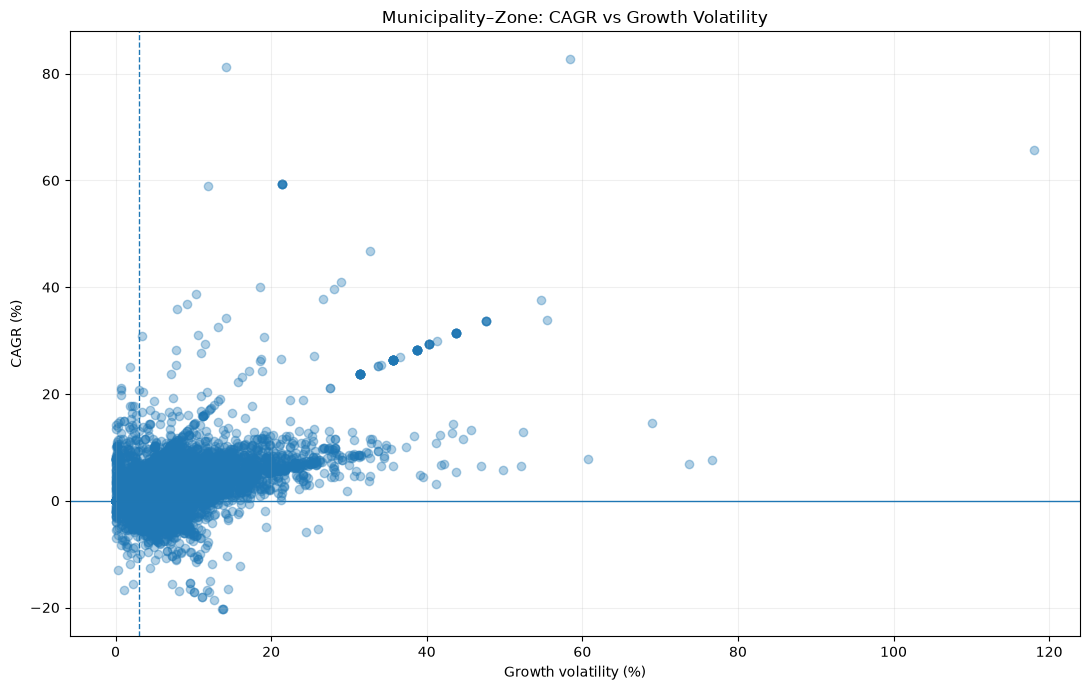

In [151]:
zone_metrics = (
    national_zone_trend
    .groupby(
        ['Comune_descrizione', 'Zona']
    )
    .agg(
        first_price=('median_compr_mid', 'first'),
        last_price=('median_compr_mid', 'last'),
        first_date=('reference_date', 'first'),
        last_date=('reference_date', 'last'),
        growth_volatility=('growth_pct', 'std'),
        max_drawdown_pct=('drawdown_pct', 'min'),
        n_periods=('reference_date', 'count'),
        total_observations=('observations', 'sum')
    )
)

zone_metrics['coverage_years'] = (
    (
        zone_metrics['last_date']
        - zone_metrics['first_date']
    ).dt.days / 365.25
)

zone_metrics['cagr_pct'] = (
    (
        zone_metrics['last_price']
        / zone_metrics['first_price']
    ) ** (
        1 / zone_metrics['coverage_years']
    ) - 1
) * 100

zone_metrics = zone_metrics[
    zone_metrics['coverage_years'] > 0
]

fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(
    zone_metrics['growth_volatility'],
    zone_metrics['cagr_pct'],
    alpha=0.35
)

ax.axhline(0, linewidth=1)
ax.axvline(
    zone_metrics['growth_volatility'].median(),
    linewidth=1,
    linestyle='--'
)

ax.set_title(
    'Municipality–Zone: CAGR vs Growth Volatility'
)

ax.set_xlabel('Growth volatility (%)')
ax.set_ylabel('CAGR (%)')

ax.grid(
    alpha=0.2
)

fig.tight_layout()
plt.show()

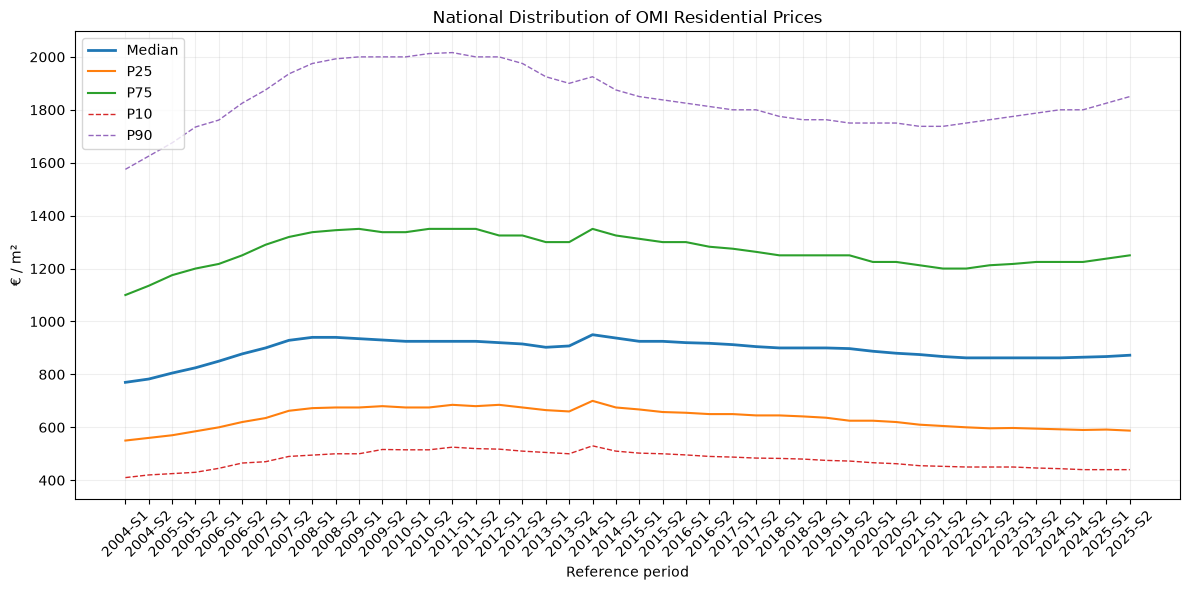

In [152]:
price_distribution = (
    national_zone_trend
    .groupby('period')['median_compr_mid']
    .quantile(
        [0.10, 0.25, 0.50, 0.75, 0.90]
    )
    .unstack()
    .reset_index()
)

price_distribution.columns = [
    'period',
    'p10',
    'p25',
    'p50',
    'p75',
    'p90'
]

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    price_distribution['period'],
    price_distribution['p50'],
    linewidth=2,
    label='Median'
)

ax.plot(
    price_distribution['period'],
    price_distribution['p25'],
    linewidth=1.5,
    label='P25'
)

ax.plot(
    price_distribution['period'],
    price_distribution['p75'],
    linewidth=1.5,
    label='P75'
)

ax.plot(
    price_distribution['period'],
    price_distribution['p10'],
    linewidth=1,
    linestyle='--',
    label='P10'
)

ax.plot(
    price_distribution['period'],
    price_distribution['p90'],
    linewidth=1,
    linestyle='--',
    label='P90'
)

ax.set_title(
    'National Distribution of OMI Residential Prices'
)

ax.set_xlabel('Reference period')
ax.set_ylabel('€ / m²')

ax.grid(alpha=0.2)

ax.legend()

plt.xticks(rotation=45)

fig.tight_layout()
plt.show()

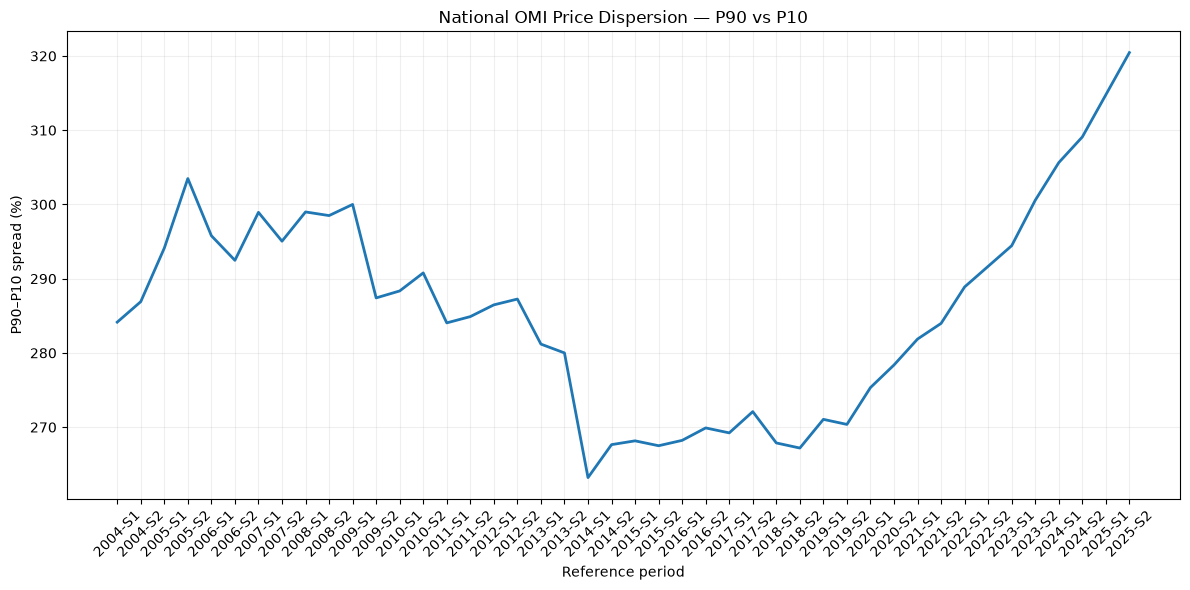

In [153]:
price_dispersion = (
    price_distribution
    .assign(
        p90_p10_spread_eur_m2=lambda x:
            x['p90'] - x['p10'],
        p75_p25_spread_eur_m2=lambda x:
            x['p75'] - x['p25'],
        p90_p10_spread_pct=lambda x:
            (
                x['p90']
                / x['p10']
                - 1
            ) * 100
    )
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    price_dispersion['period'],
    price_dispersion['p90_p10_spread_pct'],
    linewidth=2
)

ax.set_title(
    'National OMI Price Dispersion — P90 vs P10'
)

ax.set_xlabel('Reference period')
ax.set_ylabel('P90–P10 spread (%)')

ax.grid(alpha=0.2)

plt.xticks(rotation=45)

fig.tight_layout()
plt.show()

In [154]:
municipality_zone_spread = (
    national_zone_trend
    .groupby(
        ['reference_date', 'Comune_descrizione']
    )
    .agg(
        max_price=('median_compr_mid', 'max'),
        min_price=('median_compr_mid', 'min'),
        median_price=('median_compr_mid', 'median'),
        n_zones=('Zona', 'nunique')
    )
    .reset_index()
)

municipality_zone_spread['spread_eur_m2'] = (
    municipality_zone_spread['max_price']
    - municipality_zone_spread['min_price']
)

municipality_zone_spread['spread_pct'] = (
    (
        municipality_zone_spread['max_price']
        / municipality_zone_spread['min_price']
    ) - 1
) * 100

latest_date = (
    municipality_zone_spread['reference_date'].max()
)

latest_spread = (
    municipality_zone_spread[
        municipality_zone_spread['reference_date'].eq(
            latest_date
        )
    ]
    .sort_values(
        'spread_pct',
        ascending=False
    )
)

display(
    latest_spread.head(20)
)

,reference_date,Comune_descrizione,max_price,min_price,median_price,n_zones,spread_eur_m2,spread_pct
346882,2025-12-31,COURMAYEUR,10000.0,1187.50,7125.00,6,8812.50,742.105263
350252,2025-12-31,ROMA,9100.0,1100.00,2587.50,212,8000.00,727.272727
350782,2025-12-31,SAN TEODORO,3387.5,421.25,2500.00,7,2966.25,704.154303
349622,2025-12-31,PINZOLO,9500.0,1300.00,5275.00,9,8200.00,630.769231
349821,2025-12-31,PORTOFINO,16525.0,2350.00,8350.00,4,14175.00,603.191489
348247,2025-12-31,MARATEA,1775.0,275.00,1040.00,11,1500.00,545.454545
351180,2025-12-31,SESTRI LEVANTE,8075.0,1300.00,3443.75,10,6775.00,521.153846
345506,2025-12-31,CABRAS,2300.0,400.00,1133.75,4,1900.00,475.000000
349920,2025-12-31,PRE` SAINT DIDIER,6000.0,1062.50,2806.25,4,4937.50,464.705882
351461,2025-12-31,TAORMINA,4300.0,785.00,2900.00,5,3515.00,447.770701


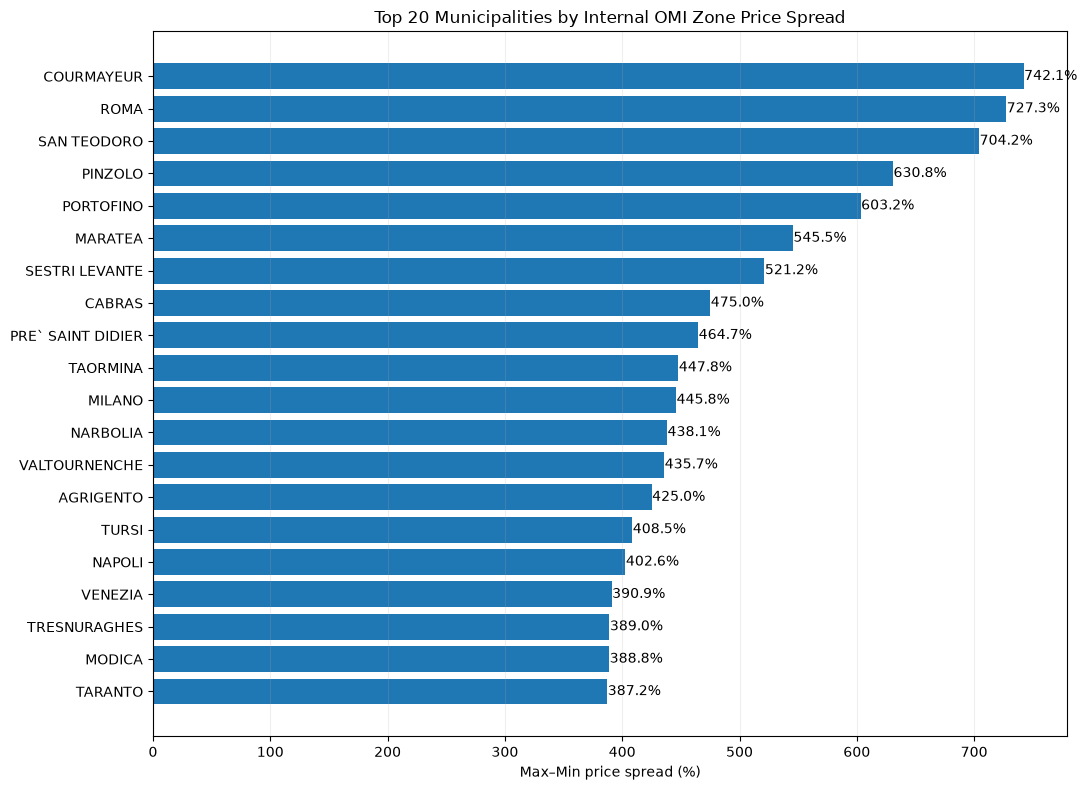

In [155]:
top_spread = (
    latest_spread
    .head(20)
    .sort_values('spread_pct')
)

fig, ax = plt.subplots(figsize=(11, 8))

labels = top_spread['Comune_descrizione']

bars = ax.barh(
    labels,
    top_spread['spread_pct']
)

for bar, value in zip(
    bars,
    top_spread['spread_pct']
):
    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center'
    )

ax.set_title(
    'Top 20 Municipalities by Internal OMI Zone Price Spread'
)

ax.set_xlabel('Max–Min price spread (%)')
ax.set_ylabel('')

ax.grid(
    axis='x',
    alpha=0.2
)

fig.tight_layout()
plt.show()

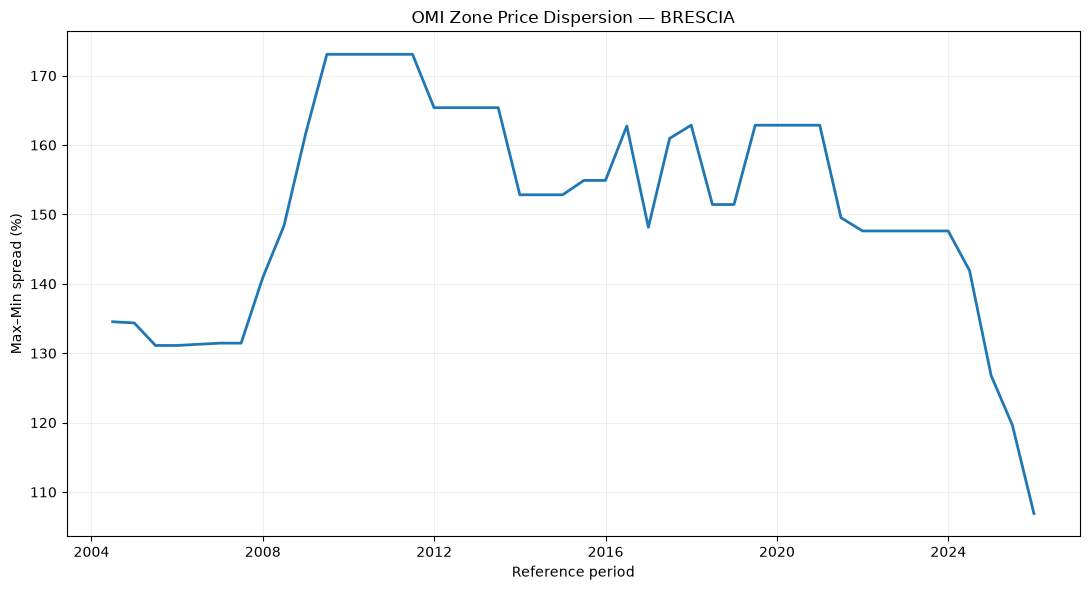

In [156]:
selected_municipality = 'BRESCIA'

municipality_history = (
    municipality_zone_spread[
        municipality_zone_spread['Comune_descrizione']
        .eq(selected_municipality)
    ]
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    municipality_history['reference_date'],
    municipality_history['spread_pct'],
    linewidth=2
)

ax.set_title(
    f'OMI Zone Price Dispersion — {selected_municipality}'
)

ax.set_xlabel('Reference period')
ax.set_ylabel('Max–Min spread (%)')

ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

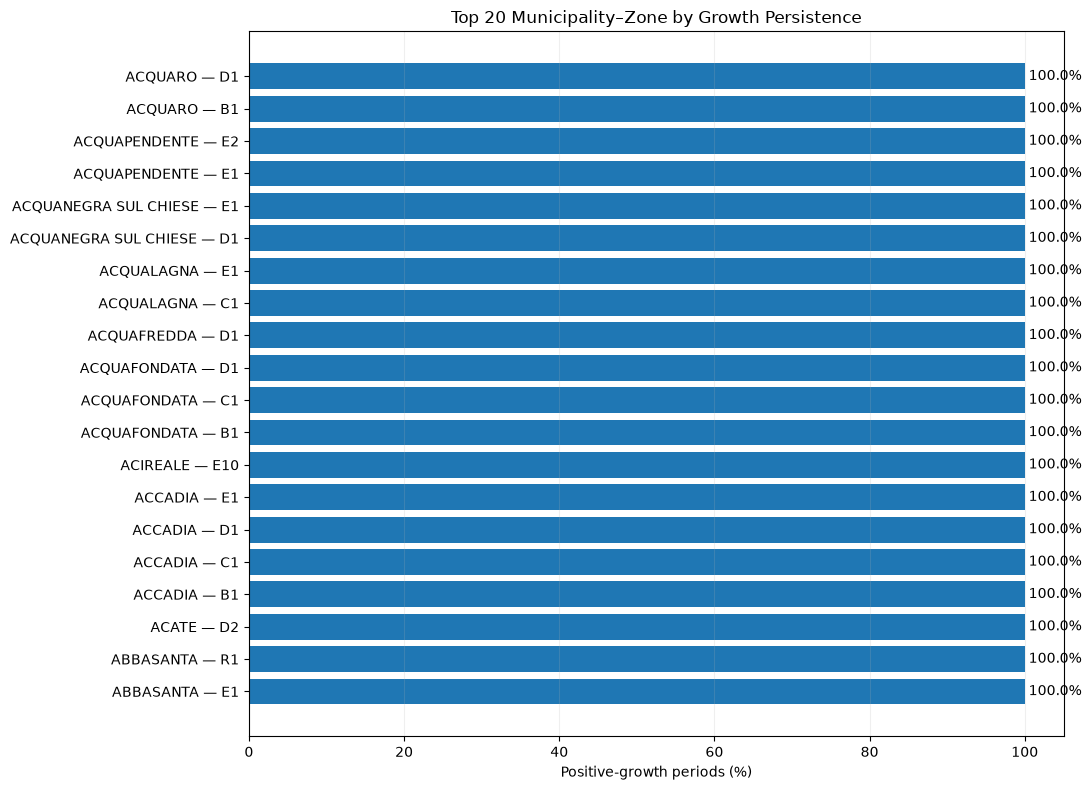

In [157]:
# Growth analysis — Municipality–Zone

growth_metrics = (
    national_zone_trend
    .groupby(
        ['Comune_descrizione', 'Zona']
    )
    .agg(
        first_price=('median_compr_mid', 'first'),
        last_price=('median_compr_mid', 'last'),
        first_date=('reference_date', 'first'),
        last_date=('reference_date', 'last'),
        mean_growth_pct=('growth_pct', 'mean'),
        growth_volatility=('growth_pct', 'std'),
        positive_periods=('growth_pct', lambda x: (x > 0).sum()),
        negative_periods=('growth_pct', lambda x: (x < 0).sum()),
        max_semester_growth_pct=('growth_pct', 'max'),
        max_semester_decline_pct=('growth_pct', 'min')
    )
)

# Coverage in years
growth_metrics['coverage_years'] = (
    (
        growth_metrics['last_date']
        - growth_metrics['first_date']
    ).dt.days / 365.25
)

# Overall price variation
growth_metrics['overall_change_pct'] = (
    (
        growth_metrics['last_price']
        / growth_metrics['first_price']
    ) - 1
) * 100

# CAGR
growth_metrics['cagr_pct'] = (
    (
        growth_metrics['last_price']
        / growth_metrics['first_price']
    ) ** (
        1 / growth_metrics['coverage_years']
    ) - 1
) * 100

# Latest YoY growth
latest_yoy = (
    national_zone_trend
    .sort_values('reference_date')
    .groupby(
        ['Comune_descrizione', 'Zona']
    )['yoy_growth_pct']
    .last()
)

growth_metrics['latest_yoy_growth_pct'] = latest_yoy

# Share of positive-growth periods
total_growth_periods = (
    growth_metrics['positive_periods']
    + growth_metrics['negative_periods']
)

growth_metrics['positive_growth_share_pct'] = (
    growth_metrics['positive_periods']
    / total_growth_periods
) * 100

growth_metrics.loc[
    total_growth_periods.eq(0),
    'positive_growth_share_pct'
] = np.nan

# Display
growth_display = growth_metrics[
    [
        'first_price',
        'last_price',
        'overall_change_pct',
        'cagr_pct',
        'latest_yoy_growth_pct',
        'mean_growth_pct',
        'growth_volatility',
        'positive_periods',
        'negative_periods',
        'positive_growth_share_pct',
        'max_semester_growth_pct',
        'max_semester_decline_pct',
        'coverage_years'
    ]
]

display(
    growth_display.head(20).style.format({
        'first_price': '€{:,.0f}',
        'last_price': '€{:,.0f}',
        'overall_change_pct': '{:.1f}%',
        'cagr_pct': '{:.1f}%',
        'latest_yoy_growth_pct': '{:.1f}%',
        'mean_growth_pct': '{:.1f}%',
        'growth_volatility': '{:.1f}%',
        'positive_growth_share_pct': '{:.1f}%',
        'max_semester_growth_pct': '{:.1f}%',
        'max_semester_decline_pct': '{:.1f}%',
        'coverage_years': '{:.1f}'
    })
) 
top_persistence = (
    growth_metrics
    .nlargest(
        20,
        'positive_growth_share_pct'
    )
    .reset_index()
    .sort_values('positive_growth_share_pct')
)

fig, ax = plt.subplots(figsize=(11, 8))

labels = (
    top_persistence['Comune_descrizione']
    + ' — '
    + top_persistence['Zona']
)

bars = ax.barh(
    labels,
    top_persistence['positive_growth_share_pct']
)

for bar, value in zip(
    bars,
    top_persistence['positive_growth_share_pct']
):
    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center'
    )

ax.set_title(
    'Top 20 Municipality–Zone by Growth Persistence'
)

ax.set_xlabel('Positive-growth periods (%)')
ax.set_ylabel('')

ax.grid(
    axis='x',
    alpha=0.2
)

fig.tight_layout()
plt.show()

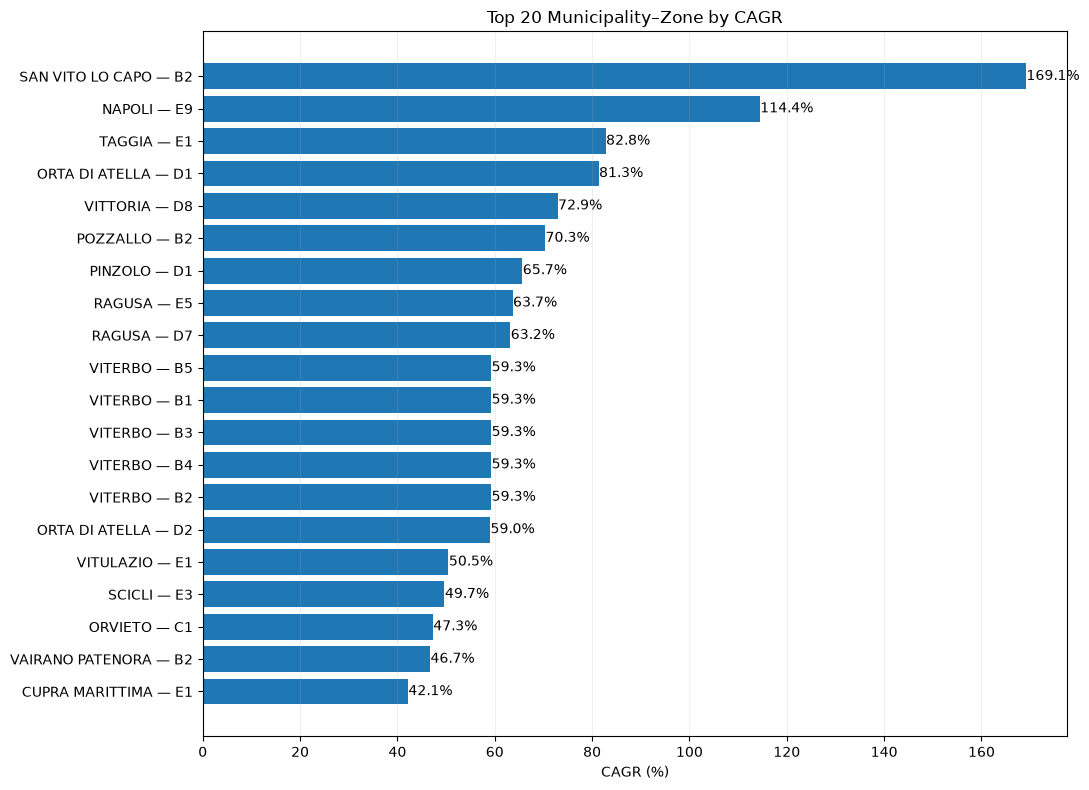

In [158]:
top_cagr = (
    growth_metrics
    .nlargest(20, 'cagr_pct')
    .reset_index()
    .sort_values('cagr_pct')
)

fig, ax = plt.subplots(figsize=(11, 8))

labels = (
    top_cagr['Comune_descrizione']
    + ' — '
    + top_cagr['Zona']
)

bars = ax.barh(
    labels,
    top_cagr['cagr_pct']
)

for bar, value in zip(
    bars,
    top_cagr['cagr_pct']
):
    ax.text(
        value + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center'
    )

ax.set_title(
    'Top 20 Municipality–Zone by CAGR'
)

ax.set_xlabel('CAGR (%)')
ax.set_ylabel('')

ax.grid(
    axis='x',
    alpha=0.2
)

fig.tight_layout()
plt.show()

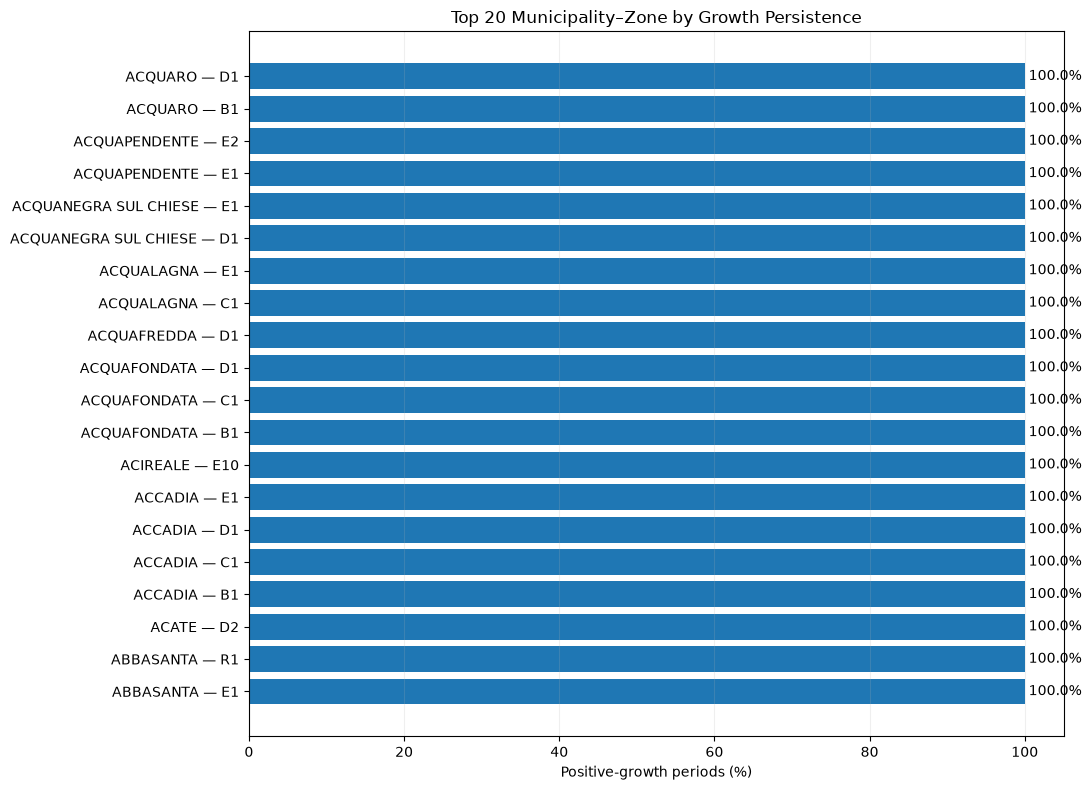

In [159]:
top_persistence = (
    growth_metrics
    .nlargest(
        20,
        'positive_growth_share_pct'
    )
    .reset_index()
    .sort_values('positive_growth_share_pct')
)

fig, ax = plt.subplots(figsize=(11, 8))

labels = (
    top_persistence['Comune_descrizione']
    + ' — '
    + top_persistence['Zona']
)

bars = ax.barh(
    labels,
    top_persistence['positive_growth_share_pct']
)

for bar, value in zip(
    bars,
    top_persistence['positive_growth_share_pct']
):
    ax.text(
        value + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center'
    )

ax.set_title(
    'Top 20 Municipality–Zone by Growth Persistence'
)

ax.set_xlabel('Positive-growth periods (%)')
ax.set_ylabel('')

ax.grid(
    axis='x',
    alpha=0.2
)

fig.tight_layout()
plt.show()